In [321]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
import pycountry

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, make_scorer, roc_auc_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

In [97]:
# correspondance = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction\CorrespondanceIndicateursFiltre.csv")

# Dataset

In [99]:
dataset = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction\\data\\dataset.csv")
dataset.drop(columns=("Unnamed: 0"),inplace=True)
dataset

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_POP_0014_FE_ZS,WB_WDI_SP_POP_1519_FE_5Y,WB_WDI_SP_POP_1519_MA_5Y,WB_WDI_SP_POP_2529_MA_5Y,WB_WDI_SP_POP_6569_MA_5Y,WB_WDI_SP_POP_65UP_FE_IN,WB_WDI_SP_POP_7074_FE_5Y,WB_WDI_SP_RUR_TOTL_ZG,WB_WDI_TG_VAL_TOTL_GD_ZS,war
0,AFG,1960,NaN,15670000.0,17180000.0,1.366750e+08,NaN,NaN,NaN,NaN,...,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN,0
1,AFG,1961,0.143791,33550000.0,34670000.0,2.684100e+08,NaN,NaN,NaN,NaN,...,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN,0
2,AFG,1962,0.142857,15260000.0,16930000.0,1.291240e+08,NaN,NaN,NaN,NaN,...,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN,0
3,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN,0
4,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7340,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,39.9351,10.8611,11.8183,6.34225,1.42023,326235.0,1.072400,1.61214,37.3596,0
7341,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,39.6584,10.8066,11.7868,6.25171,1.37936,335662.0,1.129590,1.63594,49.9734,0
7342,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,39.4349,10.7533,11.7626,6.24510,1.33185,344385.0,1.186100,1.57022,46.4750,0
7343,ZWE,2023,26.213300,509732000.0,791534000.0,7.915340e+08,14.1854,1.7896,4.7493,0.3700,...,39.1878,10.7490,11.7968,6.37652,1.27969,353070.0,1.246520,1.49648,46.6601,0


## Dataset 1 Masked

#### Récupération du dataset1

In [101]:
dataset1 = dataset.copy()

#### Shift war

In [ ]:
def shiftWar(df):
    """
    décale la variable cible (war) de 1 en arrière
    la ligne pour un pays k et une année n va avoir comme variable cible war mais pour l'année n+1

    Returns:
        shifted (pd.Dataframe) : corréspond au df d'entrée avec la variable cible décalé de 1 (changement de nom de la variable cible : war_nextYear)
    """
    df_shifted = []

    
    for country, group in df.groupby("REF_AREA"):
        g = group.copy()  # correspond au sous-dataframe de chaque pays
        g['war_nextYear'] = g['war'].shift(-1)# décaler les valeurs de war de 1 en arrière
        g = g[:-1]  # supprimer dernière année qui n'a pas de target
        df_shifted.append(g)
    # Concaténer en préservant l'ordre
    shifted = pd.concat(df_shifted, ignore_index=True)
    shifted["war_nextYear"]  = shifted['war_nextYear'].astype(int) # remettre la valeur de war_nextYear en entier
    return shifted


dataset1_shift = shiftWar(dataset1)
dataset1_shift.drop("war", axis=1, inplace=True)
dataset1_shift.drop(dataset1_shift.loc[dataset1_shift["TIME_PERIOD"] == 2011].index, inplace=True)
dataset1_shift

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_POP_0014_FE_ZS,WB_WDI_SP_POP_1519_FE_5Y,WB_WDI_SP_POP_1519_MA_5Y,WB_WDI_SP_POP_2529_MA_5Y,WB_WDI_SP_POP_6569_MA_5Y,WB_WDI_SP_POP_65UP_FE_IN,WB_WDI_SP_POP_7074_FE_5Y,WB_WDI_SP_RUR_TOTL_ZG,WB_WDI_TG_VAL_TOTL_GD_ZS,war_nextYear
0,AFG,1960,NaN,15670000.0,17180000.0,1.366750e+08,NaN,NaN,NaN,NaN,...,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN,0
1,AFG,1961,0.143791,33550000.0,34670000.0,2.684100e+08,NaN,NaN,NaN,NaN,...,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN,0
2,AFG,1962,0.142857,15260000.0,16930000.0,1.291240e+08,NaN,NaN,NaN,NaN,...,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN,0
3,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN,0
4,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,ZWE,2019,32.932400,577796000.0,845411000.0,9.534840e+08,12.6850,1.1786,4.9028,0.3527,...,40.2581,10.8588,11.7774,6.49447,1.44292,314683.0,1.010200,1.56206,35.3326,0
7228,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,39.9351,10.8611,11.8183,6.34225,1.42023,326235.0,1.072400,1.61214,37.3596,0
7229,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,39.6584,10.8066,11.7868,6.25171,1.37936,335662.0,1.129590,1.63594,49.9734,0
7230,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,39.4349,10.7533,11.7626,6.24510,1.33185,344385.0,1.186100,1.57022,46.4750,0


#### Scale LCUs

In [123]:
correspondanceIndicateur = pd.read_csv('correspondance_indicateurs.csv')
correspondanceIndicateurFiltre = correspondanceIndicateur[
    correspondanceIndicateur['id'].isin(dataset1_shift.columns)
]

# Filtre les indicateurs en current LCU

def FilterIndicatorLCU(correspondanceIndicateurFiltre):
    lcu_df = correspondanceIndicateurFiltre[
        correspondanceIndicateurFiltre['label'].str.contains('current LCU|constant LCU', case=False, na=False)
    ]
    
    # Ici on vérifie si les indicateurs en LCU ont une version en dollars, constant dollars ou en % du PIB
    correspondances = []
    for _, row in lcu_df.iterrows():
        label = row['label']
        id_ = row['id']
    
        in_usd = correspondanceIndicateurFiltre[
            correspondanceIndicateurFiltre['label'].str.contains('current US', case=False, na=False)
            & correspondanceIndicateurFiltre['label'].str.contains(label.split('(')[0].strip().split(',')[0], case=False, na=False)
        ]
    
        in_constant_usd = correspondanceIndicateurFiltre[
            correspondanceIndicateurFiltre['label'].str.contains('constant 2015 US', case=False, na=False)
            & correspondanceIndicateurFiltre['label'].str.contains(label.split('(')[0].strip().split(',')[0], case=False, na=False)
        ]
    
        in_gdp = correspondanceIndicateurFiltre[
            correspondanceIndicateurFiltre['label'].str.contains('% of GDP', case=False, na=False)
            & correspondanceIndicateurFiltre['label'].str.contains(label.split('(')[0].strip().split(',')[0], case=False, na=False)
        ]
    
        correspondances.append({
            'id': id_,
            'label': label,
            'has_usd': not in_usd.empty,
            'has_constant_usd': not in_constant_usd.empty,
            'has_gdp_percent': not in_gdp.empty
        })
    
    correspondance_df = pd.DataFrame(correspondances)
    df_filtre = correspondance_df[
        (correspondance_df['has_usd'] == False) & 
        (correspondance_df['has_constant_usd'] == False)
    ]
    return correspondance_df

correspondance_df = FilterIndicatorLCU(correspondanceIndicateurFiltre)
IndicateurAsupp = correspondance_df[(correspondance_df['has_usd']==True) | (correspondance_df['has_constant_usd']==True) | (correspondance_df['has_gdp_percent']==True)]
print(IndicateurAsupp.shape)
IndicateurAGarder = correspondance_df[(correspondance_df['has_usd']==False) & (correspondance_df['has_constant_usd']==False) & (correspondance_df['has_gdp_percent']==False)]
print(IndicateurAGarder.head())

### On a les indicateur à scaler par pays car aucun rapport entre eux en fonction de l'unité
cols_to_scale= [c for c in IndicateurAGarder['id']]


def standardCurrentLCU(dataset, cols_to_scale):
    train = dataset[dataset["TIME_PERIOD"] <= 2010]
    test  = dataset[dataset["TIME_PERIOD"] >= 2012]

    df_scaled = []
    for country,group in dataset.groupby('REF_AREA'):
        
        group = group.copy()
        train_group = group[group["TIME_PERIOD"] <= 2010]
        test_group  = group[group["TIME_PERIOD"] >= 2012]

        for col in cols_to_scale:
            mask_train = train_group[col].notna()
    
            if mask_train.sum() > 1:
                scaler = StandardScaler()
                train_group.loc[mask_train, col] = scaler.fit_transform(
                    train_group.loc[mask_train, col].values.reshape(-1,1)
                ).flatten()

                # Test
                mask_test = test_group[col].notna()
                if mask_test.sum() > 0:
                    test_group.loc[mask_test, col] = scaler.transform(
                        test_group.loc[mask_test, col].values.reshape(-1,1)
                    ).flatten()
        
        df_scaled.append(pd.concat([train_group, test_group]))
    
    return pd.concat(df_scaled, ignore_index=True) # nouveau dataset 


dataset1_shift_LCUScale = standardCurrentLCU(dataset1_shift, cols_to_scale)
dataset1_shift_LCUScale

(0, 5)
                      id                                  label  has_usd  \
0  WB_WDI_FM_LBL_BMNY_CN              Broad money (current LCU)    False   
1  WB_WDI_FM_AST_DOMS_CN      Net domestic credit (current LCU)    False   
2  WB_WDI_FM_AST_NFRG_CN       Net foreign assets (current LCU)    False   
3  WB_WDI_NE_GDI_TOTL_CN  Gross capital formation (current LCU)    False   

   has_constant_usd  has_gdp_percent  
0             False            False  
1             False            False  
2             False            False  
3             False            False  


,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_POP_0014_FE_ZS,WB_WDI_SP_POP_1519_FE_5Y,WB_WDI_SP_POP_1519_MA_5Y,WB_WDI_SP_POP_2529_MA_5Y,WB_WDI_SP_POP_6569_MA_5Y,WB_WDI_SP_POP_65UP_FE_IN,WB_WDI_SP_POP_7074_FE_5Y,WB_WDI_SP_RUR_TOTL_ZG,WB_WDI_TG_VAL_TOTL_GD_ZS,war_nextYear
0,AFG,1960,NaN,15670000.0,17180000.0,1.366750e+08,NaN,NaN,NaN,NaN,...,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN,0
1,AFG,1961,0.143791,33550000.0,34670000.0,2.684100e+08,NaN,NaN,NaN,NaN,...,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN,0
2,AFG,1962,0.142857,15260000.0,16930000.0,1.291240e+08,NaN,NaN,NaN,NaN,...,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN,0
3,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN,0
4,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,ZWE,2019,32.932400,577796000.0,845411000.0,9.534840e+08,12.6850,1.1786,4.9028,0.3527,...,40.2581,10.8588,11.7774,6.49447,1.44292,314683.0,1.010200,1.56206,35.3326,0
7115,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,39.9351,10.8611,11.8183,6.34225,1.42023,326235.0,1.072400,1.61214,37.3596,0
7116,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,39.6584,10.8066,11.7868,6.25171,1.37936,335662.0,1.129590,1.63594,49.9734,0
7117,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,39.4349,10.7533,11.7626,6.24510,1.33185,344385.0,1.186100,1.57022,46.4750,0


#### Création des colonnes lags de n-3, n-2, n-1 pour l'année n (+ suppression de 1960, 1961 et 1962 car NaN dans les lags + suppression 2002 2003 2004 2012 2013 2014)

In [125]:
dfs = []

for country, group in dataset1_shift.groupby("REF_AREA"):
    group = group.sort_values("TIME_PERIOD").copy()

    cols_to_lag = [
        col for col in group.columns
        if col not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]
    ]

    lag_frames = {}
    for lag in [1, 2, 3]:
        lag_df = group[cols_to_lag].shift(lag)
        lag_df.columns = [f"{c}_lag{lag}" for c in cols_to_lag]
        lag_frames[lag] = lag_df

    group = pd.concat([group] + list(lag_frames.values()), axis=1)

    group = group.iloc[3:]

    dfs.append(group)

dataset1_lagged = pd.concat(dfs, ignore_index=True)
for annee in [2002, 2003, 2004, 2012, 2013, 2014]: # 2002, 2003, 2004 pour validation sur train et 2012, 2013, 2014 pour test sur validation
    dataset1_lagged.drop(dataset1_lagged.loc[dataset1_lagged["TIME_PERIOD"] == annee].index, inplace=True)
dataset1_lagged

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_DYN_TO65_FE_ZS_lag3,WB_WDI_SP_POP_0014_FE_ZS_lag3,WB_WDI_SP_POP_1519_FE_5Y_lag3,WB_WDI_SP_POP_1519_MA_5Y_lag3,WB_WDI_SP_POP_2529_MA_5Y_lag3,WB_WDI_SP_POP_6569_MA_5Y_lag3,WB_WDI_SP_POP_65UP_FE_IN_lag3,WB_WDI_SP_POP_7074_FE_5Y_lag3,WB_WDI_SP_RUR_TOTL_ZG_lag3,WB_WDI_TG_VAL_TOTL_GD_ZS_lag3
0,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,21.5017,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN
1,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,22.0933,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN
2,AFG,1965,0.141026,51170000.0,53930000.0,3.788620e+08,NaN,NaN,NaN,NaN,...,22.6430,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN
3,AFG,1966,0.191449,46960000.0,50840000.0,3.428130e+08,NaN,NaN,NaN,NaN,...,23.1815,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN
4,AFG,1967,1.274860,37080000.0,41080000.0,2.768730e+08,NaN,NaN,NaN,NaN,...,23.7688,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775,ZWE,2019,32.932400,577796000.0,845411000.0,9.534840e+08,12.6850,1.1786,4.9028,0.3527,...,53.5242,41.2072,10.4084,11.0975,7.18302,1.31510,278203.0,0.939711,1.51974,42.1972
6776,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,54.6176,40.9257,10.6198,11.4015,6.86392,1.37221,290120.0,0.960355,1.52996,16.7304
6777,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,56.2024,40.5995,10.7773,11.6384,6.67529,1.42400,302353.0,0.973918,1.52873,30.5890
6778,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,56.8350,40.2581,10.8588,11.7774,6.49447,1.44292,314683.0,1.010200,1.56206,35.3326


#### Sauvegarde du dataset en CSV

In [126]:
new_order = [col for col in dataset1_lagged.columns if col != 'war_nextYear'] + ['war_nextYear']
dataset1_lagged_final = dataset1_lagged[new_order]

dataset1_lagged_final.to_csv("dataset1_lagged_final.csv", index=False)

## Dataset 2 Interpolated

#### Récupération du dataset2

In [182]:
dataset2 = dataset.copy()
dataset2

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_POP_0014_FE_ZS,WB_WDI_SP_POP_1519_FE_5Y,WB_WDI_SP_POP_1519_MA_5Y,WB_WDI_SP_POP_2529_MA_5Y,WB_WDI_SP_POP_6569_MA_5Y,WB_WDI_SP_POP_65UP_FE_IN,WB_WDI_SP_POP_7074_FE_5Y,WB_WDI_SP_RUR_TOTL_ZG,WB_WDI_TG_VAL_TOTL_GD_ZS,war
0,AFG,1960,NaN,15670000.0,17180000.0,1.366750e+08,NaN,NaN,NaN,NaN,...,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN,0
1,AFG,1961,0.143791,33550000.0,34670000.0,2.684100e+08,NaN,NaN,NaN,NaN,...,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN,0
2,AFG,1962,0.142857,15260000.0,16930000.0,1.291240e+08,NaN,NaN,NaN,NaN,...,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN,0
3,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN,0
4,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7340,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,39.9351,10.8611,11.8183,6.34225,1.42023,326235.0,1.072400,1.61214,37.3596,0
7341,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,39.6584,10.8066,11.7868,6.25171,1.37936,335662.0,1.129590,1.63594,49.9734,0
7342,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,39.4349,10.7533,11.7626,6.24510,1.33185,344385.0,1.186100,1.57022,46.4750,0
7343,ZWE,2023,26.213300,509732000.0,791534000.0,7.915340e+08,14.1854,1.7896,4.7493,0.3700,...,39.1878,10.7490,11.7968,6.37652,1.27969,353070.0,1.246520,1.49648,46.6601,0


#### Suppression des features avec plus de 25% de missing values pour au moins un pays + ajout de flag: was_interpolated

In [183]:
indicator_cols = dataset2.columns.difference(['REF_AREA', 'TIME_PERIOD','war'])

#matrice des valeurs manquantes par pays et indicateur

missing_matrix = (
    dataset2.groupby('REF_AREA')[indicator_cols]
    .apply(lambda g: g.isna().mean())
)
# On supprime les indicateurs avec trop de valeurs manquantes par pays 
# Res : 83 -> pas trop mal
missingMatrix2 = missing_matrix.copy()
for i in missingMatrix2.columns:
    if missingMatrix2[i].max()>0.25:
        missingMatrix2.drop(i,axis=1,inplace=True)


### Code pour ne garder que les colonnes présentes dans missingMatrix2

colKeep = ["REF_AREA","TIME_PERIOD", "war"]

cols_to_keep = list(missingMatrix2.columns) + colKeep
cols_to_keep = list(dict.fromkeys(cols_to_keep))  

dataset2 = dataset2[cols_to_keep]


### DATAFRAME AVEC INDICATEURS + FLAG : was_interpolated

df_flagInterpolated = dataset2.copy()
cols = [c for c in df_flagInterpolated.columns if c not in ['REF_AREA', 'TIME_PERIOD', 'war']]

for i in cols:
    df_flagInterpolated[f"{i}_was_interpolated"] = dataset2[i].isna()

dataset2 = df_flagInterpolated

# On remet REF_AREA et TIME_PERIOD en début de dataframe
new_order = ["REF_AREA", "TIME_PERIOD"] + [c for c in dataset2.columns if c not in ["REF_AREA", "TIME_PERIOD", "war"]] + ["war"]

dataset2 = dataset2[new_order]

# conversion du flag en int
## On repasse le type des colonnes 'was_interpolated' en int au lieu de bool

cols_to_convert = [
    c for c in dataset2.columns 
    if "_was_interpolated" in c
]

for col in cols_to_convert:
    dataset2[col] = dataset2[col].astype(int)

dataset2

,REF_AREA,TIME_PERIOD,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated,WB_WDI_SP_RUR_TOTL_was_interpolated,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated,WB_WDI_SP_URB_GROW_was_interpolated,WB_WDI_SP_URB_TOTL_was_interpolated,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated,war
0,AFG,1960,0.00,200.0,200.0,NaN,2606.0,140.598,546.966,598.481,...,0,0,0,0,0,0,1,0,0,0
1,AFG,1961,0.00,300.0,300.0,NaN,6109.0,139.838,540.793,592.058,...,0,0,0,0,0,0,0,0,0,0
2,AFG,1962,0.00,300.0,300.0,NaN,7016.0,139.385,535.214,586.214,...,0,0,0,0,0,0,0,0,0,0
3,AFG,1963,0.00,300.0,300.0,NaN,6681.0,139.392,529.777,580.702,...,0,0,0,0,0,0,0,0,0,0
4,AFG,1964,0.00,300.0,300.0,NaN,7079.0,139.821,523.973,575.003,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7340,ZWE,2020,21276.30,103151.0,124427.0,360506000.0,-89440.0,98.893,299.007,383.099,...,0,0,0,0,0,0,0,0,0,0
7341,ZWE,2021,5057.82,110194.0,115252.0,850710000.0,-74623.0,99.199,335.803,428.229,...,0,0,0,0,0,0,0,0,0,0
7342,ZWE,2022,8353.01,102366.0,110719.0,NaN,-102828.0,99.484,285.306,371.191,...,0,0,0,0,0,0,0,0,0,0
7343,ZWE,2023,8714.55,92005.0,100720.0,NaN,-97380.0,98.057,278.051,365.982,...,0,0,0,0,0,0,0,0,0,0


#### Shift war

In [184]:
def shiftWar(df):
    """
    décale la variable cible (war) de 1 en arrière
    la ligne pour un pays k et une année n va avoir comme variable cible war mais pour l'année n+1

    Returns:
        shifted (pd.Dataframe) : corréspond au df d'entrée avec la variable cible décalé de 1 (changement de nom de la variable cible : war_nextYear)
    """
    df_shifted = []

    
    for country, group in df.groupby("REF_AREA"):
        g = group.copy()  # correspond au sous-dataframe de chaque pays
        g['war_nextYear'] = g['war'].shift(-1)# décaler les valeurs de war de 1 en arrière
        g = g[:-1]  # supprimer dernière année qui n'a pas de target
        df_shifted.append(g)
    # Concaténer en préservant l'ordre
    shifted = pd.concat(df_shifted, ignore_index=True)
    shifted["war_nextYear"]  = shifted['war_nextYear'].astype(int) # remettre la valeur de war_nextYear en entier
    return shifted


dataset2_shift = shiftWar(dataset2)
dataset2_shift.drop("war", axis=1, inplace=True)
dataset2_shift.drop(dataset2_shift.loc[dataset2_shift["TIME_PERIOD"] == 2011].index, inplace=True)
dataset2_shift

,REF_AREA,TIME_PERIOD,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated,WB_WDI_SP_RUR_TOTL_was_interpolated,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated,WB_WDI_SP_URB_GROW_was_interpolated,WB_WDI_SP_URB_TOTL_was_interpolated,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated,war_nextYear
0,AFG,1960,0.00,200.0,200.0,NaN,2606.0,140.598,546.966,598.481,...,0,0,0,0,0,0,1,0,0,0
1,AFG,1961,0.00,300.0,300.0,NaN,6109.0,139.838,540.793,592.058,...,0,0,0,0,0,0,0,0,0,0
2,AFG,1962,0.00,300.0,300.0,NaN,7016.0,139.385,535.214,586.214,...,0,0,0,0,0,0,0,0,0,0
3,AFG,1963,0.00,300.0,300.0,NaN,6681.0,139.392,529.777,580.702,...,0,0,0,0,0,0,0,0,0,0
4,AFG,1964,0.00,300.0,300.0,NaN,7079.0,139.821,523.973,575.003,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7227,ZWE,2019,20356.00,111717.0,132073.0,419714000.0,-103107.0,98.733,313.598,389.287,...,0,0,0,0,0,0,0,0,0,0
7228,ZWE,2020,21276.30,103151.0,124427.0,360506000.0,-89440.0,98.893,299.007,383.099,...,0,0,0,0,0,0,0,0,0,0
7229,ZWE,2021,5057.82,110194.0,115252.0,850710000.0,-74623.0,99.199,335.803,428.229,...,0,0,0,0,0,0,0,0,0,0
7230,ZWE,2022,8353.01,102366.0,110719.0,NaN,-102828.0,99.484,285.306,371.191,...,0,0,0,0,0,0,0,0,0,0


#### Interpolation

In [185]:
def temporal_interpolation_per_country(df):
    """
    Applique une interpolation temporelle par pays, pour éviter tout data leakage, 
    on process sur le dataset de train et de test séparément
    """
    dfInterpole = df.copy()

    
    # Conversion TIME_PERIOD en Datetime pour pouvoir utiliser la méthode "time" de interpolate
    dfInterpole["TIME_PERIOD"] = pd.to_datetime(dfInterpole["TIME_PERIOD"], format='%Y')
    # on le met en index
    dfInterpole = dfInterpole.set_index("TIME_PERIOD")
    # Colonnes à interpoler
    col_to_interp = [c for c in dfInterpole.columns if c not in ["REF_AREA",'war_nextYear'] and "_was_interpolated" not in c]
    print(f"avant interpolation : {dfInterpole.isna().sum().sum()}")
    #  Interpolation temporelle 
    interpolated = (
        dfInterpole.groupby("REF_AREA")[col_to_interp]
        .apply(lambda g: g.sort_index().interpolate(method="time", limit_direction='both', limit=5))
    )
    # ça créer des multiindex, donc on retirer REF_AREA
    dfInterpole[col_to_interp] = interpolated.droplevel(0)
    print("Après time :", dfInterpole[col_to_interp].isna().sum().sum())
    
    # Dans le cas où la méthode time n'a pas pu tout interpoler (pas assez de point, des points isolés..)
    interpolated = (
        dfInterpole.groupby("REF_AREA")[col_to_interp]
        .apply(lambda g: g.sort_index().interpolate(method="linear", limit_direction='both'))
    )
    dfInterpole[col_to_interp] = interpolated.droplevel(0)
    print("Après linear :", dfInterpole[col_to_interp].isna().sum().sum())
    
 
    # on remet TIME_PERIOD en colonne après le traintement
    dfInterpole = dfInterpole.reset_index()
    dfInterpole["TIME_PERIOD"] = dfInterpole["TIME_PERIOD"].dt.year.astype(int)
    return dfInterpole
    

dataset2_shift_a_interpoler = dataset2_shift.copy()

features = dataset2_shift_a_interpoler.columns.tolist()

test = dataset2_shift_a_interpoler[dataset2_shift_a_interpoler['TIME_PERIOD']>2011]
train_tot  = dataset2_shift_a_interpoler[dataset2_shift_a_interpoler['TIME_PERIOD']<=2011] # jeu de train+validation 
train = train_tot[train_tot['TIME_PERIOD']<=2001] # jeu de train uniquement pour la validation
validation  = train_tot[train_tot['TIME_PERIOD']>2001] # jeu de validation

print("interpolation train")    
train_interpolated = temporal_interpolation_per_country(train)
print("interpolation validation")
validation_interpolated  = temporal_interpolation_per_country(validation)
print("interpolation train_tot")    
train_tot_interpolated = temporal_interpolation_per_country(train_tot)
print("interpolation test")
test_interpolated  = temporal_interpolation_per_country(test)

dataset2_shift_interpolated = pd.concat([train_interpolated, validation_interpolated, test_interpolated])
dataset2_shift_interpolated

interpolation train
avant interpolation : 1368
Après time : 565
Après linear : 0
interpolation validation
avant interpolation : 0
Après time : 0
Après linear : 0
interpolation train_tot
avant interpolation : 1368
Après time : 565
Après linear : 0
interpolation test
avant interpolation : 245
Après time : 0
Après linear : 0


,TIME_PERIOD,REF_AREA,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated,WB_WDI_SP_RUR_TOTL_was_interpolated,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated,WB_WDI_SP_URB_GROW_was_interpolated,WB_WDI_SP_URB_TOTL_was_interpolated,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated,war_nextYear
0,1960,AFG,0.00,200.0,200.0,0.0,2606.0,140.598,546.966,598.481,...,0,0,0,0,0,0,1,0,0,0
1,1961,AFG,0.00,300.0,300.0,0.0,6109.0,139.838,540.793,592.058,...,0,0,0,0,0,0,0,0,0,0
2,1962,AFG,0.00,300.0,300.0,0.0,7016.0,139.385,535.214,586.214,...,0,0,0,0,0,0,0,0,0,0
3,1963,AFG,0.00,300.0,300.0,0.0,6681.0,139.392,529.777,580.702,...,0,0,0,0,0,0,0,0,0,0
4,1964,AFG,0.00,300.0,300.0,0.0,7079.0,139.821,523.973,575.003,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351,2019,ZWE,20356.00,111717.0,132073.0,419714000.0,-103107.0,98.733,313.598,389.287,...,0,0,0,0,0,0,0,0,0,0
1352,2020,ZWE,21276.30,103151.0,124427.0,360506000.0,-89440.0,98.893,299.007,383.099,...,0,0,0,0,0,0,0,0,0,0
1353,2021,ZWE,5057.82,110194.0,115252.0,850710000.0,-74623.0,99.199,335.803,428.229,...,0,0,0,0,0,0,0,0,0,0
1354,2022,ZWE,8353.01,102366.0,110719.0,850710000.0,-102828.0,99.484,285.306,371.191,...,0,0,0,0,0,0,0,0,0,0


#### Création des colonnes lags de n-3, n-2, n-1 pour l'année n (+ suppression de 1960, 1961 et 1962 car NaN dans les lags + suppression 2002 2003 2004 2012 2013 2014)

In [186]:
dfs = []

for country, group in dataset2_shift_interpolated.groupby("REF_AREA"):
    group = group.sort_values("TIME_PERIOD").copy()

    cols_to_lag = [
        col for col in group.columns
        if col not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]
    ]

    lag_frames = {}
    for lag in [1, 2, 3]:
        lag_df = group[cols_to_lag].shift(lag)
        lag_df.columns = [f"{c}_lag{lag}" for c in cols_to_lag]
        lag_frames[lag] = lag_df

    group = pd.concat([group] + list(lag_frames.values()), axis=1)

    group = group.iloc[3:]

    dfs.append(group)

dataset2_shift_interpolated_lagged = pd.concat(dfs, ignore_index=True)
for annee in [2002, 2003, 2004, 2012, 2013, 2014]: # 2002, 2003, 2004 pour validation sur train et 2012, 2013, 2014 pour test sur validation
    dataset2_shift_interpolated_lagged.drop(dataset2_shift_interpolated_lagged.loc[dataset2_shift_interpolated_lagged["TIME_PERIOD"] == annee].index, inplace=True)
dataset2_shift_interpolated_lagged

,TIME_PERIOD,REF_AREA,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated_lag3,WB_WDI_SP_URB_GROW_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated_lag3
0,1963,AFG,0.00,300.0,300.0,0.0,6681.0,139.392,529.777,580.702,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1964,AFG,0.00,300.0,300.0,0.0,7079.0,139.821,523.973,575.003,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1965,AFG,0.00,300.0,300.0,0.0,10695.0,140.822,518.310,569.683,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1966,AFG,0.00,300.0,300.0,0.0,3563.0,141.668,512.486,564.221,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1967,AFG,0.00,400.0,400.0,0.0,6824.0,141.451,506.817,558.762,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775,2019,ZWE,20356.00,111717.0,132073.0,419714000.0,-103107.0,98.733,313.598,389.287,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6776,2020,ZWE,21276.30,103151.0,124427.0,360506000.0,-89440.0,98.893,299.007,383.099,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6777,2021,ZWE,5057.82,110194.0,115252.0,850710000.0,-74623.0,99.199,335.803,428.229,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6778,2022,ZWE,8353.01,102366.0,110719.0,850710000.0,-102828.0,99.484,285.306,371.191,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Standard Scaler pour PCA

In [187]:
def StandardisationStandard(train, test, cols_to_scale):
    train_scaled = train.copy()
    test_scaled = test.copy()

    train_log = train.copy()
    test_log = test.copy()
    
    scaler = StandardScaler()
    scaler.fit(train_log[cols_to_scale])

    train_scaled[cols_to_scale] = scaler.transform(train_log[cols_to_scale]) 
    test_scaled[cols_to_scale] = scaler.transform(test_log[cols_to_scale]) 
    
    return train_scaled, test_scaled
    

dataset2_shift_interpolated_lagged_to_scaled = dataset2_shift_interpolated_lagged.copy()
train = dataset2_shift_interpolated_lagged_to_scaled[dataset2_shift_interpolated_lagged_to_scaled["TIME_PERIOD"] <= 2010]
test = dataset2_shift_interpolated_lagged_to_scaled[dataset2_shift_interpolated_lagged_to_scaled["TIME_PERIOD"] >= 2012]
X_train = train.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])

cols_to_scale = [
    c for c in train.columns 
    if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"] and "_was_interpolated" not in c
]

train_scaled, test_scaled = StandardisationStandard(train, test, cols_to_scale)
dataset2_shift_interpolated_lagged_scaled = pd.concat([train_scaled, test_scaled])
dataset2_shift_interpolated_lagged_scaled

,TIME_PERIOD,REF_AREA,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated_lag3,WB_WDI_SP_URB_GROW_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated_lag3
0,1963,AFG,-0.088641,-0.333019,-0.207776,-0.099340,0.059096,0.873136,2.534536,2.223027,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1964,AFG,-0.088641,-0.333019,-0.207776,-0.099340,0.061437,0.881427,2.485227,2.175779,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1965,AFG,-0.088641,-0.333019,-0.207776,-0.099340,0.082702,0.900772,2.437117,2.131674,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1966,AFG,-0.088641,-0.333019,-0.207776,-0.099340,0.040759,0.917121,2.387638,2.086391,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1967,AFG,-0.088641,-0.332942,-0.207741,-0.099340,0.059937,0.912927,2.339477,2.041133,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775,2019,ZWE,-0.077707,-0.246589,-0.161707,0.110933,-0.586566,0.087387,0.697965,0.636102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6776,2020,ZWE,-0.077212,-0.253234,-0.164381,0.081270,-0.506190,0.090479,0.574005,0.584801,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6777,2021,ZWE,-0.085924,-0.247770,-0.167588,0.326858,-0.419052,0.096393,0.886610,0.958951,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6778,2022,ZWE,-0.084154,-0.253843,-0.169173,0.326858,-0.584925,0.101900,0.457607,0.486078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Vérification 0 NaN dans dataset2 même avec colonnes lagged

In [188]:
print(dataset2_shift_interpolated_lagged.isna().sum().sum())
print(dataset2_shift_interpolated_lagged_scaled.isna().sum().sum())

0
0


#### Réorganisation colonne avec war_nextYear à la fin + Sauvegarde du dataset en CSV

In [189]:
cols = ['war']
new_order = [col for col in dataset2_shift_interpolated_lagged.columns if col != 'war_nextYear'] + ['war_nextYear']
dataset2_lagged_final = dataset2_shift_interpolated_lagged[new_order]

dataset2_lagged_final.to_csv("dataset2_lagged_final.csv", index=False)

#### PCA (optionnel)

In [190]:
def applyPCA(X_train, X_test, cols_to_drop, n_components=0.95,verbose= False):
    """
    Applique la PCA, visualise les résultats et renvoie les données transformées
    
    Args:
        n_components: float (0.95) pour garder 95% de variance
    """
    print("DEBUT PCA")
    
    # Nettoyage : On retire les colonnes spécifiées 
    X_train_clean = X_train.drop(columns=cols_to_drop)
    X_test_clean = X_test.drop(columns=cols_to_drop)

    # Calcul PCA
    pca = PCA(n_components=n_components, random_state=42)
    
    X_train_pca = pca.fit_transform(X_train_clean)
    X_test_pca = pca.transform(X_test_clean)
    
    # Création des DataFrames propres (On garde l'index d'origine)
    pca_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
    
    df_train_pca = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
    df_test_pca = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)

    if verbose:
        print(f"Dimensions originales : {X_train_clean.shape}")
        print(f"Dimensions PCA        : {df_train_pca.shape} (pour {n_components*100}% de variance)")
        print(f"Variance expliquée    : {pca.explained_variance_ratio_.sum():.4f}")

        # visualisation
    
        # A-Variance Cumulée
        plt.figure(figsize=(10, 4))
        cumulative_variance = pca.explained_variance_ratio_.cumsum()
        plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
        plt.axhline(y=0.95, color='r', linestyle='-', alpha=0.5, label='95% Seuil')
        plt.title('PCA - Variance Expliquée Cumulée')
        plt.xlabel('Nombre de Composantes')
        plt.ylabel('Variance')
        plt.grid(True)
        plt.legend()
        plt.show()

    # On regarde les loadings (poids) des variables sur les composantes
    loadings = pd.DataFrame(
        pca.components_.T,
        index=X_train_clean.columns,
        columns=pca_cols
    )
    
    # On sélectionne les 20 variables qui pèsent le plus lourd au total
    top_vars = loadings.abs().sum(axis=1).sort_values(ascending=False).head(20).index
    
    # On affiche la Heatmap limité aux 5 premières PC 
    cols_to_show = pca_cols[:10] if len(pca_cols) > 10 else pca_cols
    
    if verbose:
        plt.figure(figsize=(12, 6))
        sns.heatmap(loadings.loc[top_vars, cols_to_show], cmap="coolwarm", center=0)
        plt.title("PCA - Top 20 Variables contribuantes (Loadings)")
        plt.show()

    return df_train_pca, df_test_pca, pca


# colonnes à exclure
cols_not_pca = [c for c in train_interpolated.columns if "_was_interpolated" in c]


DEBUT PCA
Dimensions originales : (5085, 581)
Dimensions PCA        : (5085, 16) (pour 95.0% de variance)
Variance expliquée    : 0.9508


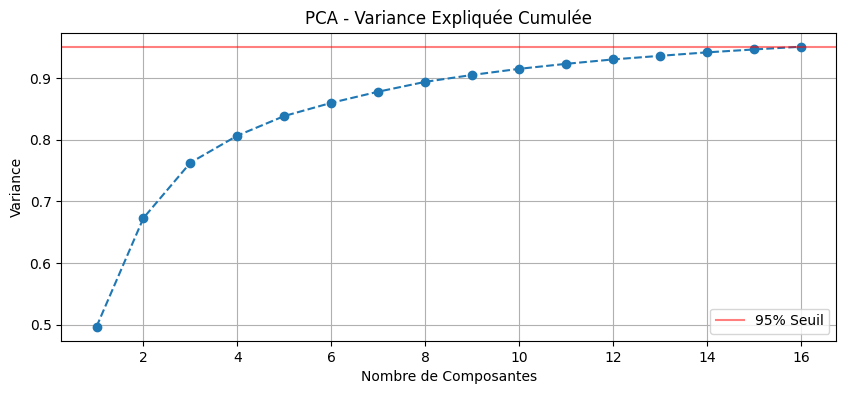

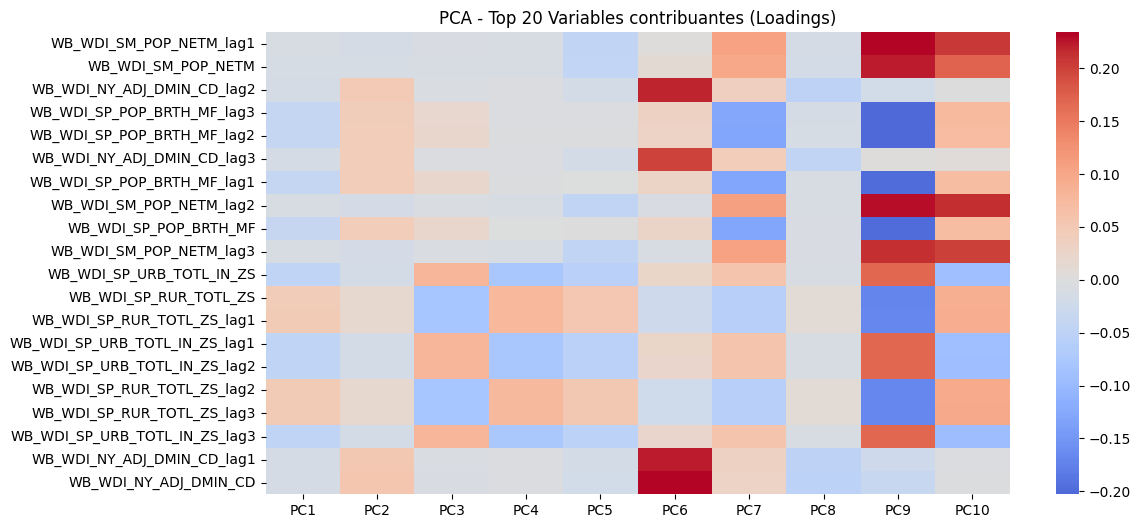

DEBUT PCA
Dimensions originales : (4068, 581)
Dimensions PCA        : (4068, 17) (pour 95.0% de variance)
Variance expliquée    : 0.9518


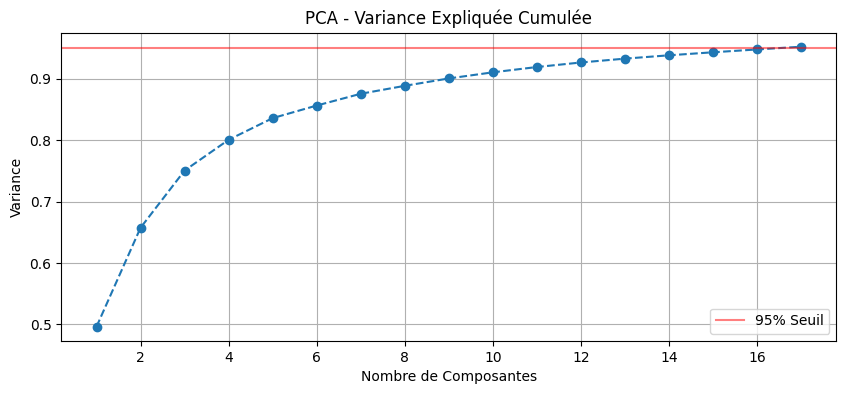

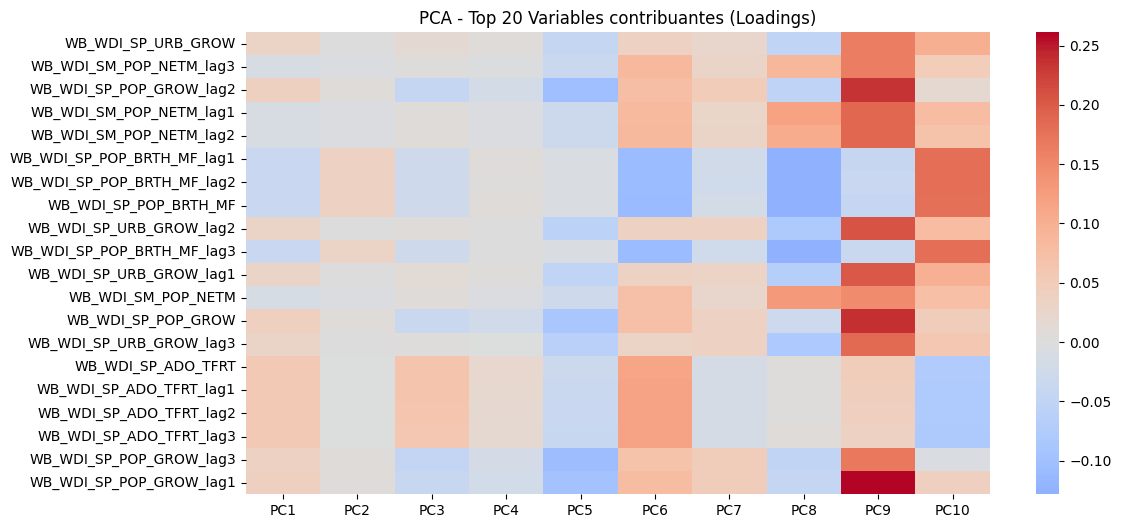

In [191]:
train_full = dataset2_shift_interpolated_lagged_scaled[dataset2_shift_interpolated_lagged_scaled["TIME_PERIOD"] <= 2010]
test  = dataset2_shift_interpolated_lagged_scaled[dataset2_shift_interpolated_lagged_scaled["TIME_PERIOD"] >= 2012]

X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])

split_year = train_full["TIME_PERIOD"].quantile(0.8)
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])


X_train_tot_pca, X_test_pca, pca_modelTrainTest = applyPCA(
    X_train_full, 
    X_test, 
    cols_to_drop=cols_not_pca,
    n_components=0.95,
    verbose=True
)


X_train_pca, X_validation_pca, pca_modelValidation = applyPCA(
    X_train_train, 
    X_train_val, 
    cols_to_drop=cols_not_pca,
    n_components=0.95,
    verbose=True
) 

# Train

## Dataset 1 Masked

#### Récupération du dataset1

In [341]:
dataset1 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset1_lagged_final.csv")
dataset1

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_POP_0014_FE_ZS_lag3,WB_WDI_SP_POP_1519_FE_5Y_lag3,WB_WDI_SP_POP_1519_MA_5Y_lag3,WB_WDI_SP_POP_2529_MA_5Y_lag3,WB_WDI_SP_POP_6569_MA_5Y_lag3,WB_WDI_SP_POP_65UP_FE_IN_lag3,WB_WDI_SP_POP_7074_FE_5Y_lag3,WB_WDI_SP_RUR_TOTL_ZG_lag3,WB_WDI_TG_VAL_TOTL_GD_ZS_lag3,war_nextYear
0,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN,0
1,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN,0
2,AFG,1965,0.141026,51170000.0,53930000.0,3.788620e+08,NaN,NaN,NaN,NaN,...,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN,0
3,AFG,1966,0.191449,46960000.0,50840000.0,3.428130e+08,NaN,NaN,NaN,NaN,...,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN,0
4,AFG,1967,1.274860,37080000.0,41080000.0,2.768730e+08,NaN,NaN,NaN,NaN,...,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6097,ZWE,2019,32.932400,577796000.0,845411000.0,9.534840e+08,12.6850,1.1786,4.9028,0.3527,...,41.2072,10.4084,11.0975,7.18302,1.31510,278203.0,0.939711,1.51974,42.1972,0
6098,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,40.9257,10.6198,11.4015,6.86392,1.37221,290120.0,0.960355,1.52996,16.7304,0
6099,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,40.5995,10.7773,11.6384,6.67529,1.42400,302353.0,0.973918,1.52873,30.5890,0
6100,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,40.2581,10.8588,11.7774,6.49447,1.44292,314683.0,1.010200,1.56206,35.3326,0


#### Découpage train/validation/test

In [342]:
train_full = dataset1[dataset1["TIME_PERIOD"] <= 2010]
test  = dataset1[dataset1["TIME_PERIOD"] >= 2012]

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

print(f"Dataset1   => {dataset1.shape}")
print(f"Train_full => {train_full.shape}")
print(f"Test       => {test.shape}")
print(f"Train_full : X_train_full => {X_train_full.shape} - y_train_full => {y_train_full.shape}")
print(f"Test       : X_test       => {X_test.shape} - y_test       => {y_test.shape}")

print(f"X_train_train => {X_train_train.shape}")
print(f"y_train_train => {y_train_train.shape}")
print(f"X_train_val   => {X_train_val.shape}")
print(f"y_train_val   => {y_train_val.shape}")

Dataset1   => (6102, 883)
Train_full => (5085, 883)
Test       => (1017, 883)
Train_full : X_train_full => (5085, 880) - y_train_full => (5085,)
Test       : X_test       => (1017, 880) - y_test       => (1017,)
X_train_train => (4068, 880)
y_train_train => (4068,)
X_train_val   => (1017, 880)
y_train_val   => (1017,)


#### Réduction nombre de feature par covariance

<Figure size 1200x1200 with 0 Axes>

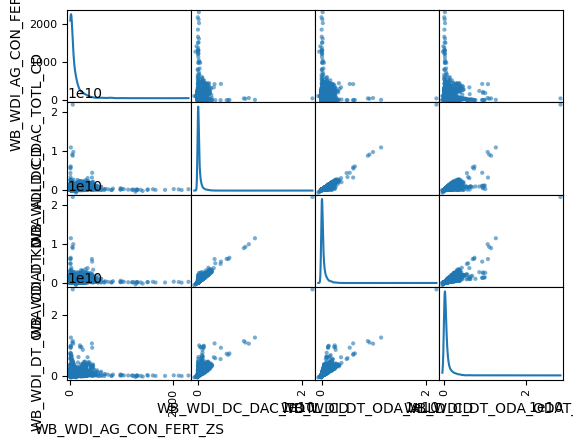

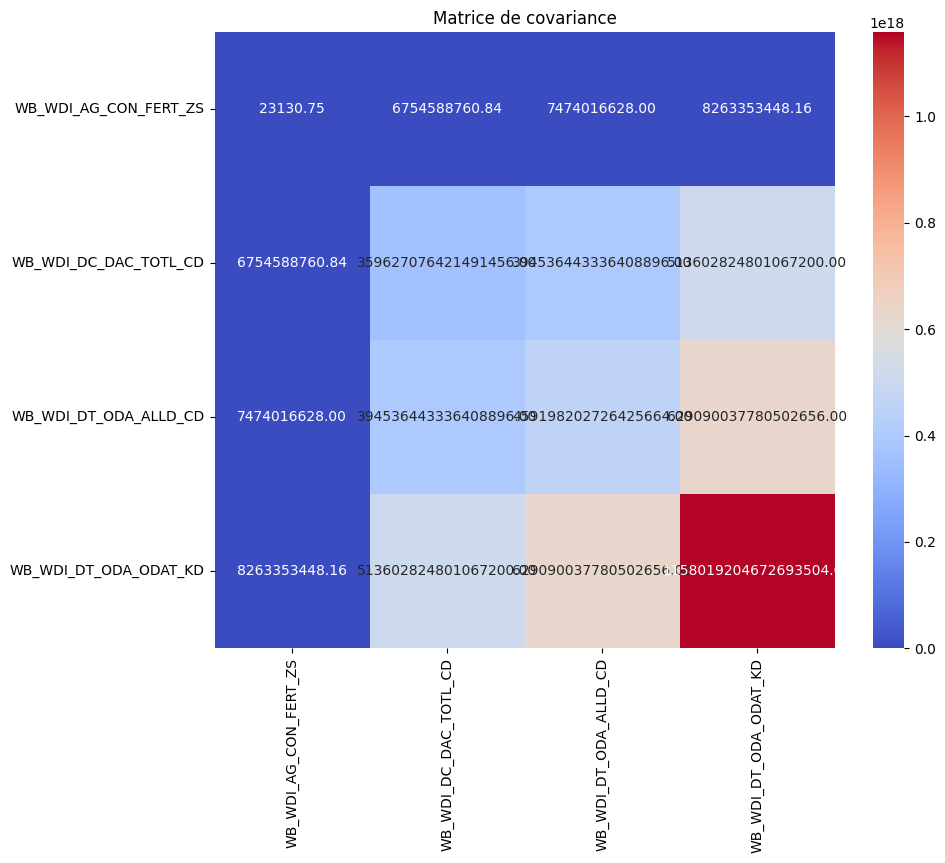

Colonnes à supprimer (628): {'WB_WDI_SP_POP_0509_MA_5Y_lag3', 'WB_WDI_SP_POP_0014_TO', 'WB_WDI_NY_GDP_MKTP_KD_lag1', 'WB_WDI_SP_DYN_LE00_FE_IN_lag2', 'WB_WDI_SP_POP_80UP_MA_5Y_lag3', 'WB_WDI_EN_GHG_CH4_IC_MT_CE_AR5_lag3', 'WB_WDI_SP_POP_80UP_FE_5Y', 'WB_WDI_FM_LBL_BMNY_CN_lag3', 'WB_WDI_SP_ADO_TFRT_lag1', 'WB_WDI_AG_LND_PRCP_MM_lag3', 'WB_WDI_NE_IMP_GNFS_CD_lag3', 'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5_lag1', 'WB_WDI_SP_DYN_IMRT_MA_IN_lag3', 'WB_WDI_SP_POP_0014_TO_lag3', 'WB_WDI_AG_LND_AGRI_K2_lag3', 'WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5', 'WB_WDI_NY_GNP_PCAP_CD_lag3', 'WB_WDI_SP_POP_65UP_TO', 'WB_WDI_DT_ODA_ALLD_KD_lag2', 'WB_WDI_SP_POP_65UP_TO_ZS', 'WB_WDI_EN_GHG_CO2_PC_CE_AR5_lag1', 'WB_WDI_EN_GHG_N2O_IP_MT_CE_AR5_lag2', 'WB_WDI_EN_GHG_ALL_MT_CE_AR5_lag1', 'WB_WDI_AG_PRD_LVSK_XD_lag1', 'WB_WDI_SE_PRM_AGES_lag3', 'WB_WDI_SP_POP_3539_MA_5Y_lag1', 'WB_WDI_SP_POP_5054_MA_5Y_lag1', 'WB_WDI_SP_POP_6569_MA_5Y_lag3', 'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5_lag3', 'WB_WDI_FI_RES_XGLD_CD', 'WB_WDI_TX_VAL_MRCH_WL_

In [343]:
cols_subset = train_full.select_dtypes(include='number').columns[1:5]

plt.figure(figsize=(12,12))
pd.plotting.scatter_matrix(train_full[cols_subset], alpha=0.6, diagonal='kde')  # 'kde' pour la distribution sur la diagonale
plt.show()



cov_matrix = train_full[cols_subset].cov()

# numeric_df = dataset1.select_dtypes(include='number')
# cov_matrix = numeric_df.cov()

plt.figure(figsize=(10,8))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de covariance")
plt.show()


cols_to_check = [c for c in train_full.columns if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]]
data_numeric = train_full[cols_to_check]
corr_matrix = data_numeric.corr().abs()
threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

print(f"Colonnes à supprimer ({len(to_drop)}):", to_drop)
train_full = train_full.drop(columns=list(to_drop))
test = test.drop(columns=list(to_drop))
print("Shape après réduction :", train_full.shape)
print("Shape après réduction :", test.shape)


# REFAIRE LES DECOUPAGES

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

print(f"Dataset1   => {dataset1.shape}")
print(f"Train_full => {train_full.shape}")
print(f"Test       => {test.shape}")
print(f"Train_full : X_train_full => {X_train_full.shape} - y_train_full => {y_train_full.shape}")
print(f"Test       : X_test       => {X_test.shape} - y_test       => {y_test.shape}")

print(f"X_train_train => {X_train_train.shape}")
print(f"y_train_train => {y_train_train.shape}")
print(f"X_train_val   => {X_train_val.shape}")
print(f"y_train_val   => {y_train_val.shape}")

In [353]:
print(X_train_train.isna().sum().sum())
import sklearn
print(sklearn.__version__)

196191
1.6.0


#### XGBoost

##### Hyperparameter tunning

In [327]:
# scale_pos_weight = y_train_full.value_counts()[0] / y_train_full.value_counts()[1]

# # Définition du modèle
# xgb_model = xgb.XGBClassifier(
#     scale_pos_weight=scale_pos_weight,
#     random_state=42,
#     eval_metric='logloss',
#     n_jobs=-1
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)


##### Entraînement avec meilleur hyperparamètre

In [328]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_xgb_1 = xgb.XGBClassifier(
    n_estimators=300, #100
    max_depth=7, #3
    learning_rate=0.1, #0.05
    subsample=0.8, #1.0
    colsample_bytree=1.0, #0.8
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
    # objective="binary:logistic",
    # use_label_encoder=False
)

# Entraînement
model_xgb_1.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_train, y_train_train), (X_train_val, y_train_val)], 
    # eval_set=[(X_train_val, y_train_val)], 
    # early_stopping_rounds=30,
    verbose=False
)

# Prédiction
y_train_pred = model_xgb_1.predict(X_train_train)
y_val_pred = model_xgb_1.predict(X_train_val)
y_val_probs = model_xgb_1.predict_proba(X_train_val)[:, 1]

# Évaluation
acc_xgb_d1 = accuracy_score(y_train_val, y_val_pred)
precision_xgb_d1 = precision_score(y_train_val, y_val_pred)
recall_xgb_d1 = recall_score(y_train_val, y_val_pred)
f1_train_xgb_d1 = f1_score(y_train_train, y_train_pred)
f1_val_xgb_d1 = f1_score(y_train_val, y_val_pred)
gap_xgb_d1 = f1_train_xgb_d1 - f1_val_xgb_d1
roc_auc_xgb_d1 = roc_auc_score(y_train_val, y_val_probs)

print("Accuracy :", acc_xgb_d1)
print("Precision:", precision_xgb_d1)
print("Recall   :", recall_xgb_d1)
print("F1-score train :", f1_train_xgb_d1)
print("F1-score val   :", f1_val_xgb_d1)
print("Gap (F1-train - F1-val) :", gap_xgb_d1)
print("ROC-AUC :", roc_auc_xgb_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.856440511307768
Precision: 0.874384236453202
Recall   : 0.7888888888888889
F1-score train : 1.0
F1-score val   : 0.8294392523364486
Gap (F1-train - F1-val) : 0.17056074766355145
ROC-AUC : 0.9267568097197727

Confusion matrix:
 [[516  51]
 [ 95 355]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.88       567
           1       0.87      0.79      0.83       450

    accuracy                           0.86      1017
   macro avg       0.86      0.85      0.85      1017
weighted avg       0.86      0.86      0.86      1017



##### Feature importance

Top 20 features par importance :
                          Feature  Importance
0           WB_WDI_AG_LND_CREL_HA    0.116826
1           WB_WDI_AG_LND_PRCP_MM    0.027879
2              WB_WDI_SG_LAW_INDX    0.021380
3      WB_WDI_DC_DAC_DEUL_CD_lag1    0.018443
4           WB_WDI_DC_DAC_DEUL_CD    0.018205
5      WB_WDI_DC_DAC_DEUL_CD_lag2    0.015499
6           WB_WDI_NV_AGR_TOTL_ZS    0.014110
7        WB_WDI_NY_ADJ_AEDU_GN_ZS    0.011489
8        WB_WDI_SP_POP_0014_FE_IN    0.011264
9        WB_WDI_SP_POP_65UP_FE_ZS    0.010547
10          WB_WDI_AG_LND_AGRI_K2    0.010540
11  WB_WDI_TX_VAL_MRCH_WR_ZS_lag2    0.010519
12  WB_WDI_NY_ADJ_AEDU_GN_ZS_lag1    0.010378
13          WB_WDI_AG_LND_ARBL_ZS    0.010185
14          WB_WDI_SP_POP_BRTH_MF    0.010001
15  WB_WDI_TX_VAL_MRCH_WR_ZS_lag3    0.009235
16       WB_WDI_EN_URB_MCTY_TL_ZS    0.008873
17          WB_WDI_ER_H2O_INTR_PC    0.008537
18          WB_WDI_SP_POP_DPND_YG    0.008235
19  WB_WDI_TX_VAL_MRCH_RS_ZS_lag3    0.008182


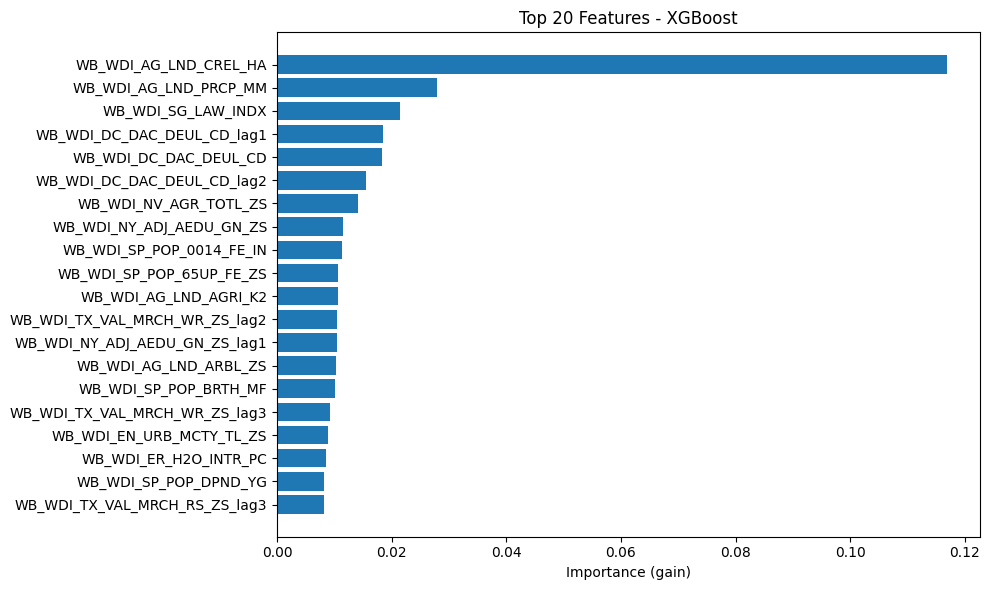

In [329]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_xgb_1

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

# Récupérer la feature importance par gain
importance_dict = best_model.get_booster().get_score(importance_type='gain')

# Convertir en DataFrame pour trier et afficher
importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher le tableau complet ou top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'].head(20)[::-1],
    importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (gain)')
plt.title('Top 20 Features - XGBoost')
plt.tight_layout()
plt.show()

In [330]:
# # Assurer que ton modèle est déjà entraîné : best_model = model_xgb
# best_model = model_xgb

# # 1️⃣ Créer l'explainer SHAP pour XGBoost
# explainer = shap.TreeExplainer(best_model)

# # 2️⃣ Calculer les valeurs SHAP sur l'ensemble d'entraînement
# shap_values = explainer.shap_values(X_train_train.astype(np.float32).values)

# # 3️⃣ Moyenne des valeurs absolues par feature pour obtenir l'importance globale
# shap_importance = np.abs(shap_values).mean(axis=0)

# # 4️⃣ Créer un DataFrame pour trier
# importance_df = pd.DataFrame({
#     'Feature': X_train_train.columns,
#     'SHAP Importance': shap_importance
# }).sort_values(by='SHAP Importance', ascending=False).reset_index(drop=True)

# # 5️⃣ Afficher les 20 premières features
# print("Top 20 features par SHAP importance :")
# print(importance_df.head(20))

# # 6️⃣ Graphique top 20
# plt.figure(figsize=(10,6))
# plt.barh(
#     importance_df['Feature'].head(20)[::-1],
#     importance_df['SHAP Importance'].head(20)[::-1]
# )
# plt.xlabel('Mean |SHAP value|')
# plt.title('Top 20 Features - SHAP Importance (XGBoost)')
# plt.tight_layout()
# plt.show()


#### CatBoost

##### Hyperparameter tunning

In [331]:
# # Définition du modèle
# cat_model = CatBoostClassifier(
#     random_state=42,
#     verbose=0   # IMPORTANT pour GridSearch
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'depth': [3, 5, 7],                 # max_depth → depth
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bylevel': [0.7, 0.8, 1.0]  # colsample_bytree → colsample_bylevel
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=cat_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)


##### Entraînement avec meilleur hyperparamètre

In [332]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_cat_1 = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=[1, scale_pos_weight],   # Classe 0 = poids 1, classe 1 = poids > 1
    random_seed=42,
    eval_metric="F1",
    loss_function="Logloss",
    verbose=0,
    early_stopping_rounds=30,
    # task_type="CPU",
)

# Entraînement
model_cat_1.fit(
    X_train_train, 
    y_train_train,
    eval_set=(X_train_val, y_train_val),
    verbose=0,           # affiche toutes les 50 itérations, mettre 0 pour silence total
    plot=False
)

# Prédiction
y_train_pred = model_cat_1.predict(X_train_train)
y_val_pred = model_cat_1.predict(X_train_val)
y_val_probs = model_cat_1.predict_proba(X_train_val)[:, 1]

# Évaluation
acc_cat_d1 = accuracy_score(y_train_val, y_val_pred)
precision_cat_d1 = precision_score(y_train_val, y_val_pred)
recall_cat_d1 = recall_score(y_train_val, y_val_pred)
f1_train_cat_d1 = f1_score(y_train_train, y_train_pred)
f1_val_cat_d1 = f1_score(y_train_val, y_val_pred)
gap_cat_d1 = f1_train_cat_d1 - f1_val_cat_d1
roc_auc_cat_d1 = roc_auc_score(y_train_val, y_val_probs)

print("Accuracy :", acc_cat_d1)
print("Precision:", precision_cat_d1)
print("Recall   :", recall_cat_d1)
print("F1-score train :", f1_train_cat_d1)
print("F1-score val   :", f1_val_cat_d1)
print("Gap (F1-train - F1-val) :", gap_cat_d1)
print("ROC-AUC :", roc_auc_cat_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8505408062930186
Precision: 0.8130252100840336
Recall   : 0.86
F1-score train : 0.9656992084432717
F1-score val   : 0.8358531317494601
Gap (F1-train - F1-val) : 0.12984607669381165
ROC-AUC : 0.9141289437585733

Confusion matrix:
 [[478  89]
 [ 63 387]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       567
           1       0.81      0.86      0.84       450

    accuracy                           0.85      1017
   macro avg       0.85      0.85      0.85      1017
weighted avg       0.85      0.85      0.85      1017



##### Feature importance

Top 20 features par importance :
                       Feature  Importance
0        WB_WDI_AG_LND_CREL_HA    7.337486
1     WB_WDI_SP_POP_0014_FE_IN    4.741194
2        WB_WDI_AG_LND_AGRI_ZS    3.339407
3        WB_WDI_ER_H2O_INTR_K3    2.947705
4        WB_WDI_SP_POP_BRTH_MF    2.809595
5     WB_WDI_EN_URB_MCTY_TL_ZS    2.767714
6        WB_WDI_NY_GDP_PCAP_KD    2.697783
7           WB_WDI_EN_POP_DNST    2.115360
8     WB_WDI_SP_POP_5559_FE_5Y    1.852204
9     WB_WDI_SP_POP_4044_MA_5Y    1.753781
10    WB_WDI_AG_LND_ARBL_HA_PC    1.624336
11  WB_WDI_FM_AST_NFRG_CN_lag3    1.619845
12       WB_WDI_AG_LND_PRCP_MM    1.376070
13       WB_WDI_AG_LND_ARBL_ZS    1.340028
14       WB_WDI_FM_AST_NFRG_CN    1.217243
15          WB_WDI_EN_URB_LCTY    1.185460
16       WB_WDI_SP_DYN_AMRT_MA    1.137072
17  WB_WDI_DC_DAC_DEUL_CD_lag1    1.066326
18     WB_WDI_PA_NUS_FCRF_lag2    1.033379
19    WB_WDI_EN_URB_LCTY_UR_ZS    1.013321


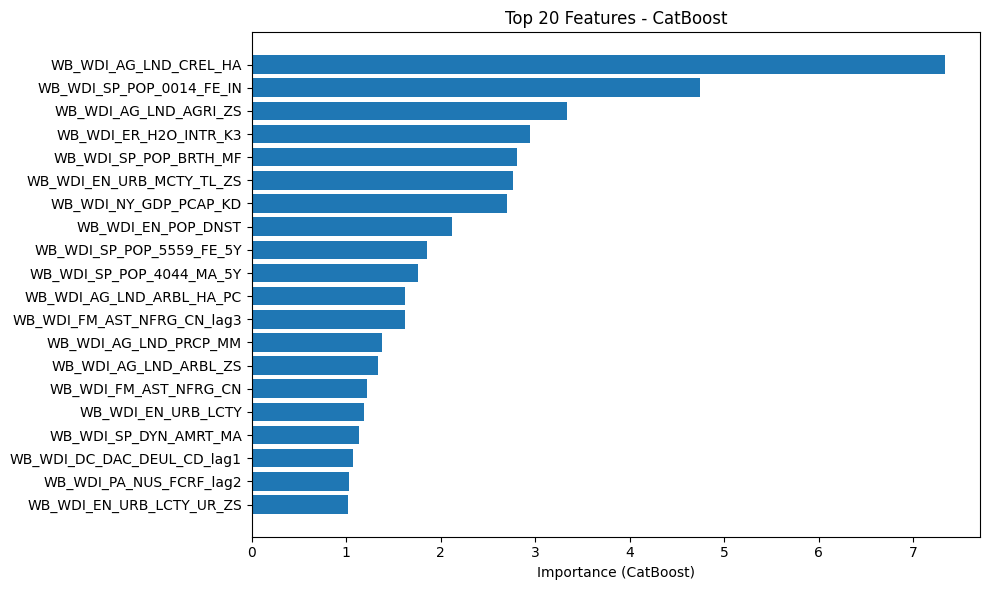

In [333]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_cat_1

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.get_feature_importance()

# Construire le DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Trier
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (CatBoost)')
plt.title('Top 20 Features - CatBoost')
plt.tight_layout()
plt.show()


#### Random Forest

##### Hyperparameter tunning

In [334]:
# # Définition du modèle
# rf_model = RandomForestClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 5],
#     'max_features': ['sqrt', 'log2']
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=rf_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)


##### Entraînement avec meilleur hyperparamètre

In [351]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_rf_1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15, # Pour limiter overfitting, sinon None
    # class_weight={0: 1, 1: scale_pos_weight},   # équivalent au class_weights catboost
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entraînement
model_rf_1.fit(
    X_train_train, 
    y_train_train
)

# Prédiction
y_train_pred = model_rf_1.predict(X_train_train)
y_val_pred = model_rf_1.predict(X_train_val)
y_val_probs = model_rf_1.predict_proba(X_train_val)[:, 1]

# Évaluation
acc_rf_d1 = accuracy_score(y_train_val, y_val_pred)
precision_rf_d1 = precision_score(y_train_val, y_val_pred)
recall_rf_d1 = recall_score(y_train_val, y_val_pred)
f1_train_rf_d1 = f1_score(y_train_train, y_train_pred)
f1_val_rf_d1 = f1_score(y_train_val, y_val_pred)
gap_rf_d1 = f1_train_rf_d1 - f1_val_rf_d1
roc_auc_rf_d1 = roc_auc_score(y_train_val, y_val_probs)

print("Accuracy :", acc_rf_d1)
print("Precision:", precision_rf_d1)
print("Recall   :", recall_rf_d1)
print("F1-score train :", f1_train_rf_d1)
print("F1-score val   :", f1_val_rf_d1)
print("Gap (F1-train - F1-val) :", gap_rf_d1)
print("ROC-AUC :", roc_auc_rf_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8662733529990168
Precision: 0.9025641025641026
Recall   : 0.7822222222222223
F1-score train : 0.9997071742313324
F1-score val   : 0.8380952380952381
Gap (F1-train - F1-val) : 0.16161193613609426
ROC-AUC : 0.9212659220066628

Confusion matrix:
 [[529  38]
 [ 98 352]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.93      0.89       567
           1       0.90      0.78      0.84       450

    accuracy                           0.87      1017
   macro avg       0.87      0.86      0.86      1017
weighted avg       0.87      0.87      0.86      1017



##### Feature importance

Top 20 features par importance :
                           Feature  Importance
0         WB_WDI_SP_POP_0014_FE_IN    0.032930
1            WB_WDI_AG_LND_CREL_HA    0.024391
2            WB_WDI_AG_LND_ARBL_HA    0.018004
3               WB_WDI_SH_DTH_MORT    0.016854
4               WB_WDI_EN_POP_DNST    0.012521
5            WB_WDI_ER_H2O_INTR_K3    0.011458
6       WB_WDI_DC_DAC_DEUL_CD_lag3    0.010872
7            WB_WDI_NY_GDP_PCAP_KD    0.010854
8   WB_WDI_EN_GHG_N2O_WA_MT_CE_AR5    0.010678
9            WB_WDI_AG_LND_ARBL_ZS    0.010595
10        WB_WDI_EN_URB_MCTY_TL_ZS    0.010269
11           WB_WDI_DC_DAC_DEUL_CD    0.009491
12              WB_WDI_EN_URB_LCTY    0.009274
13           WB_WDI_ER_FSH_CAPT_MT    0.008757
14      WB_WDI_DC_DAC_DEUL_CD_lag2    0.008431
15           WB_WDI_AG_LND_AGRI_ZS    0.008267
16           WB_WDI_NV_AGR_TOTL_ZS    0.008242
17           WB_WDI_SP_POP_BRTH_MF    0.007781
18           WB_WDI_ER_FSH_PROD_MT    0.007762
19        WB_WDI_EN_URB_LCT

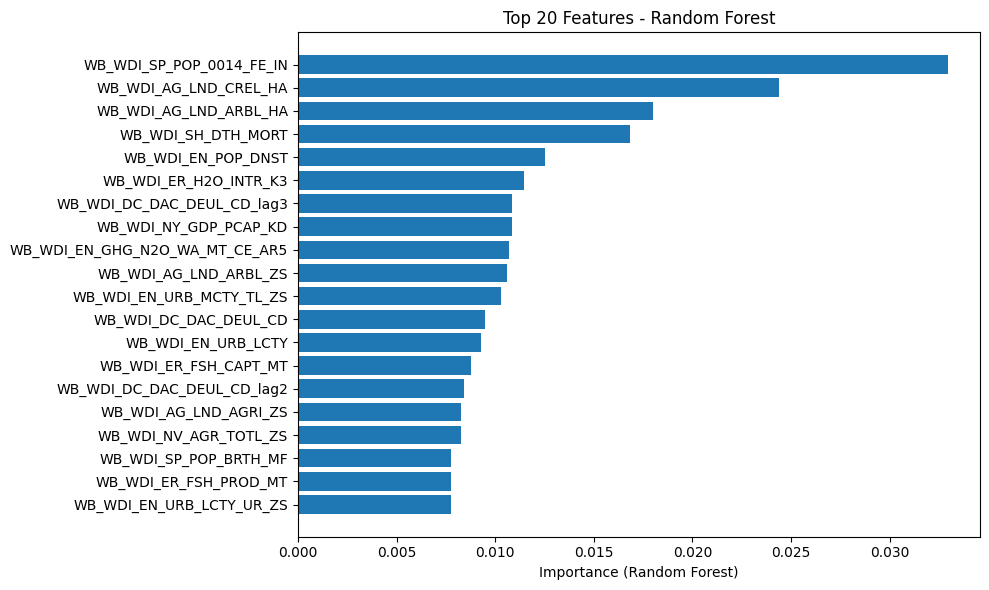

In [336]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_rf_1

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features par importance :")
print(importance_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (Random Forest)')
plt.title('Top 20 Features - Random Forest')
plt.tight_layout()
plt.show()


#### LightBM

##### Hyperparameter tunning

In [337]:
# # Définition du modèle
# lgb_model = lgb.LGBMClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=lgb_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)

##### Entraînement avec meilleur hyperparamètre

In [338]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_lgb_1 = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    objective='binary',
    # early_stopping_rounds=30,
    verbose=0
)

# Entraînement
model_lgb_1.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_val, y_train_val)], 
    eval_metric='binary_logloss'
)

# Prédiction
y_train_pred = model_lgb_1.predict(X_train_train)
y_val_pred = model_lgb_1.predict(X_train_val)
y_val_probs = model_lgb_1.predict_proba(X_train_val)[:, 1]

# Évaluation
acc_lgb_d1 = accuracy_score(y_train_val, y_val_pred)
precision_lgb_d1 = precision_score(y_train_val, y_val_pred)
recall_lgb_d1 = recall_score(y_train_val, y_val_pred)
f1_train_lgb_d1 = f1_score(y_train_train, y_train_pred)
f1_val_lgb_d1 = f1_score(y_train_val, y_val_pred)
gap_lgb_d1 = f1_train_lgb_d1 - f1_val_lgb_d1
roc_auc_lgb_d1 = roc_auc_score(y_train_val, y_val_probs)

print("Accuracy :", acc_lgb_d1)
print("Precision:", precision_lgb_d1)
print("Recall   :", recall_lgb_d1)
print("F1-score train :", f1_train_lgb_d1)
print("F1-score val   :", f1_val_lgb_d1)
print("Gap (F1-train - F1-val) :", gap_lgb_d1)
print("ROC-AUC :", roc_auc_lgb_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8613569321533924
Precision: 0.8584686774941995
Recall   : 0.8222222222222222
F1-score train : 1.0
F1-score val   : 0.8399545970488081
Gap (F1-train - F1-val) : 0.16004540295119185
ROC-AUC : 0.9338937879678619

Confusion matrix:
 [[506  61]
 [ 80 370]]

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.88       567
           1       0.86      0.82      0.84       450

    accuracy                           0.86      1017
   macro avg       0.86      0.86      0.86      1017
weighted avg       0.86      0.86      0.86      1017



##### Feature importance

Top 20 features par importance :
                     Feature  Importance
0   WB_WDI_EN_URB_MCTY_TL_ZS         154
1         WB_WDI_EN_POP_DNST         147
2      WB_WDI_ER_H2O_INTR_K3         146
3   WB_WDI_SP_POP_0014_FE_IN         142
4   WB_WDI_EN_URB_LCTY_UR_ZS         129
5      WB_WDI_SP_DYN_AMRT_MA         121
6   WB_WDI_AG_LND_ARBL_HA_PC         113
7      WB_WDI_ER_H2O_INTR_PC         112
8      WB_WDI_SP_POP_BRTH_MF         107
9      WB_WDI_NY_GDP_PCAP_KD         103
10     WB_WDI_FM_AST_DOMS_CN          98
11        WB_WDI_SH_DTH_MORT          95
12     WB_WDI_AG_LND_AGRI_ZS          94
13     WB_WDI_AG_LND_PRCP_MM          91
14     WB_WDI_NE_GDI_TOTL_CN          90
15        WB_WDI_SM_POP_NETM          88
16     WB_WDI_NY_GDP_DEFL_ZS          86
17        WB_WDI_SG_LAW_INDX          83
18     WB_WDI_ER_FSH_PROD_MT          81
19        WB_WDI_SH_DYN_MORT          80


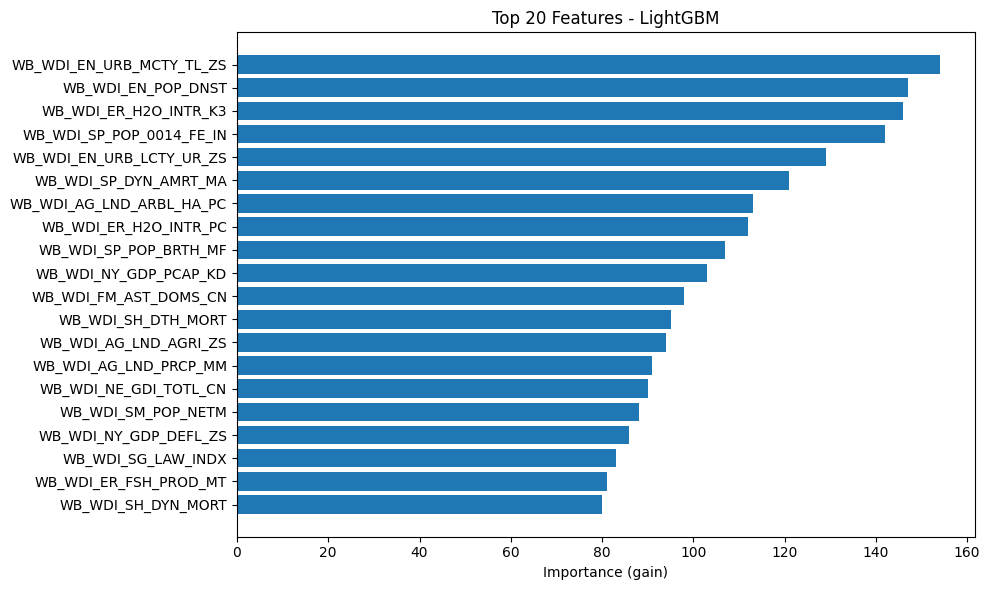

In [339]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_lgb_1

# Si tu as un GridSearchCV pour LightGBM :
# best_model = grid_search.best_estimator_

# Récupérer la feature importance (par gain)
feature_names = X_train_train.columns
importance = best_model.feature_importances_

# Convertir en DataFrame pour trier et afficher
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher le tableau complet ou top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (gain)')
plt.title('Top 20 Features - LightGBM')
plt.tight_layout()
plt.show()


#### Tableau récap dataset 1

In [340]:
data_dataset1 = {
        'Model': ['XGBoost', 'CatBoost', 'RandomForest', 'LightGBM'],
        'Accuracy': [f"{acc_xgb_d1:.4f}",
                        f"{acc_cat_d1:.4f}",
                        f"{acc_rf_d1:.4f}",
                        f"{acc_lgb_d1:.4f}"],
        'Precision': [f"{precision_xgb_d1:.4f}",
                        f"{precision_cat_d1:.4f}",
                        f"{precision_rf_d1:.4f}",
                        f"{precision_lgb_d1:.4f}"],
        'Recall': [f"{recall_xgb_d1:.4f}",
                        f"{recall_cat_d1:.4f}",
                        f"{recall_rf_d1:.4f}",
                        f"{recall_lgb_d1:.4f}"],
        'F1-score train': [f"{f1_train_xgb_d1:.4f}",
                        f"{f1_train_cat_d1:.4f}",
                        f"{f1_train_rf_d1:.4f}",
                        f"{f1_train_lgb_d1:.4f}"],
        'F1-score val': [f"{f1_val_xgb_d1:.4f}",
                        f"{f1_val_cat_d1:.4f}",
                        f"{f1_val_rf_d1:.4f}",
                        f"{f1_val_lgb_d1:.4f}"],
        'Gap ': [f"{gap_xgb_d1:.4f}",
                f"{gap_cat_d1:.4f}",
                f"{gap_rf_d1:.4f}",
                f"{gap_lgb_d1:.4f}"],
        'ROC AUC ': [f"{roc_auc_xgb_d1:.4f}",
                        f"{roc_auc_cat_d1:.4f}",
                        f"{roc_auc_rf_d1:.4f}",
                        f"{roc_auc_lgb_d1:.4f}"],
}

df_results = pd.DataFrame(data_dataset1)
df_results

,Model,Accuracy,Precision,Recall,F1-score train,F1-score val,Gap,ROC AUC
0,XGBoost,0.8564,0.8744,0.7889,1.0000,0.8294,0.1706,0.9268
1,CatBoost,0.8505,0.8130,0.8600,0.9657,0.8359,0.1298,0.9141
2,RandomForest,0.8663,0.9026,0.7822,0.9997,0.8381,0.1616,0.9213
3,LightGBM,0.8614,0.8585,0.8222,1.0000,0.8400,0.1600,0.9339


## Dataset 2 Interpolated sans PCA

#### Récupération du dataset2

In [29]:
dataset2 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset2_lagged_final.csv")
dataset2

,REF_AREA,TIME_PERIOD,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated_lag3,WB_WDI_SP_URB_GROW_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated_lag3,war_nextYear
0,AFG,1963,-0.010893,-0.159337,-0.163188,-0.018595,0.270270,0.555559,1.589105,1.597300,...,False,False,False,False,False,False,True,False,False,0
1,AFG,1964,-0.010893,-0.159337,-0.163188,-0.018595,0.280237,0.560557,1.559453,1.563872,...,False,False,False,False,False,False,False,False,False,0
2,AFG,1965,-0.010893,-0.159337,-0.163188,-0.018595,0.370794,0.572219,1.530522,1.532668,...,False,False,False,False,False,False,False,False,False,0
3,AFG,1966,-0.010893,-0.159337,-0.163188,-0.018595,0.192184,0.582076,1.500768,1.500631,...,False,False,False,False,False,False,False,False,False,0
4,AFG,1967,-0.010893,-0.158912,-0.162791,-0.018595,0.273851,0.579547,1.471805,1.468611,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6436,ZWE,2019,3.624107,0.313896,0.360988,36.741186,-2.479208,0.081857,0.484677,0.474558,...,False,False,False,False,False,False,False,False,False,0
6437,ZWE,2020,3.788446,0.277513,0.330573,31.555576,-2.136938,0.083721,0.410134,0.438263,...,False,False,False,False,False,False,False,False,False,0
6438,ZWE,2021,0.892289,0.307427,0.294076,74.489079,-1.765868,0.087286,0.598119,0.702972,...,False,False,False,False,False,False,False,False,False,0
6439,ZWE,2022,1.480716,0.274178,0.276045,74.489079,-2.472220,0.090607,0.340137,0.368417,...,False,False,False,False,False,False,False,False,False,0


In [30]:
cols_to_check = [c for c in dataset2.columns if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]]
data_numeric = dataset2[cols_to_check]
corr_matrix = data_numeric.corr().abs()
threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

print(f"Colonnes à supprimer ({len(to_drop)}):", to_drop)
dataset2 = dataset2.drop(columns=list(to_drop))
print("Shape après réduction :", dataset2.shape)

Colonnes à supprimer (295): {'WB_WDI_SP_POP_TOTL_lag2', 'WB_WDI_SP_DYN_LE00_FE_IN_lag3', 'WB_WDI_SP_POP_65UP_FE_IN_lag3', 'WB_WDI_SP_DYN_LE00_MA_IN_was_interpolated_lag3', 'WB_WDI_SP_POP_0509_MA_5Y_lag3', 'WB_WDI_SP_POP_TOTL_FE_ZS_lag2', 'WB_WDI_SP_POP_3034_MA_5Y_lag1', 'WB_WDI_SP_POP_0014_TO', 'WB_WDI_SP_DYN_AMRT_MA_was_interpolated_lag1', 'WB_WDI_SP_DYN_LE00_FE_IN_lag2', 'WB_WDI_SP_POP_7579_FE_5Y_lag2', 'WB_WDI_SP_POP_7074_FE_5Y_lag3', 'WB_WDI_SP_DYN_CBRT_IN_lag3', 'WB_WDI_SP_POP_80UP_FE_5Y', 'WB_WDI_SP_POP_0004_MA_5Y_lag2', 'WB_WDI_SP_POP_80UP_MA_5Y_lag3', 'WB_WDI_SP_POP_1564_TO_ZS_lag3', 'WB_WDI_SP_POP_2529_FE_5Y_lag3', 'WB_WDI_SP_POP_TOTL_MA_IN', 'WB_WDI_SP_POP_DPND', 'WB_WDI_SP_POP_1014_FE_5Y_lag3', 'WB_WDI_SP_POP_80UP_MA_5Y_lag2', 'WB_WDI_SP_POP_0004_MA_5Y_lag1', 'WB_WDI_SP_ADO_TFRT_lag1', 'WB_WDI_SP_POP_0014_MA_IN_lag3', 'WB_WDI_SP_POP_1564_TO_ZS', 'WB_WDI_SP_POP_TOTL_FE_ZS_lag3', 'WB_WDI_SP_POP_2024_MA_5Y_lag3', 'WB_WDI_SP_POP_1564_MA_ZS', 'WB_WDI_SP_POP_1564_FE_ZS_lag1', 'WB_

#### Découpage train/validation/test

In [31]:
train_full = dataset2[dataset2["TIME_PERIOD"] <= 2010]
test  = dataset2[dataset2["TIME_PERIOD"] >= 2012]

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

print(f"Dataset2   => {dataset2.shape}")
print(f"Train_full => {train_full.shape}")
print(f"Test       => {test.shape}")
print(f"Train_full : X_train_full => {X_train_full.shape} - y_train_full => {y_train_full.shape}")
print(f"Test       : X_test       => {X_test.shape} - y_test       => {y_test.shape}")

print(f"X_train_train => {X_train_train.shape}")
print(f"y_train_train => {y_train_train.shape}")
print(f"X_train_val   => {X_train_val.shape}")
print(f"y_train_val   => {y_train_val.shape}")

Dataset2   => (6441, 372)
Train_full => (5424, 372)
Test       => (1017, 372)
Train_full : X_train_full => (5424, 369) - y_train_full => (5424,)
Test       : X_test       => (1017, 369) - y_test       => (1017,)
X_train_train => (4407, 369)
y_train_train => (4407,)
X_train_val   => (1017, 369)
y_train_val   => (1017,)


#### XGBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [32]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_xgb_2 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Entraînement
model_xgb_2.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_train, y_train_train), (X_train_val, y_train_val)], 
    verbose=False
)

# Prédiction
y_val_pred = model_xgb_2.predict(X_train_val)

# Évaluation
acc_xgb_d2 = accuracy_score(y_train_val, y_val_pred)
f1_xgb_d2 = f1_score(y_train_val, y_val_pred)
precision_xgb_d2 = precision_score(y_train_val, y_val_pred)
recall_xgb_d2 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_xgb_d2)
print("F1-score :", f1_xgb_d2)
print("Precision:", precision_xgb_d2)
print("Recall   :", recall_xgb_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8544739429695182
F1-score : 0.8266978922716628
Precision: 0.863080684596577
Recall   : 0.7932584269662921

Confusion matrix:
 [[516  56]
 [ 92 353]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       572
           1       0.86      0.79      0.83       445

    accuracy                           0.85      1017
   macro avg       0.86      0.85      0.85      1017
weighted avg       0.85      0.85      0.85      1017



##### Feature importance

Top 20 features par importance :
                                           Feature  Importance
0                         WB_WDI_SP_POP_0014_FE_IN    0.089648
1                         WB_WDI_SP_POP_5559_FE_5Y    0.043810
2                            WB_WDI_ER_FSH_CAPT_MT    0.035754
3                            WB_WDI_SP_POP_BRTH_MF    0.034624
4      WB_WDI_NY_ADJ_DMIN_CD_was_interpolated_lag1    0.031570
5      WB_WDI_NY_ADJ_DMIN_CD_was_interpolated_lag3    0.029276
6   WB_WDI_SP_DYN_LE00_FE_IN_was_interpolated_lag3    0.027511
7                            WB_WDI_NY_ADJ_DMIN_CD    0.027270
8                       WB_WDI_SP_DYN_CDRT_IN_lag2    0.026070
9                         WB_WDI_SP_POP_4044_MA_5Y    0.024877
10                      WB_WDI_SP_DYN_CDRT_IN_lag3    0.024639
11                        WB_WDI_SP_POP_TOTL_FE_ZS    0.024222
12                           WB_WDI_SP_RUR_TOTL_ZS    0.021845
13                           WB_WDI_SP_DYN_AMRT_FE    0.021206
14          WB_WDI_NY_

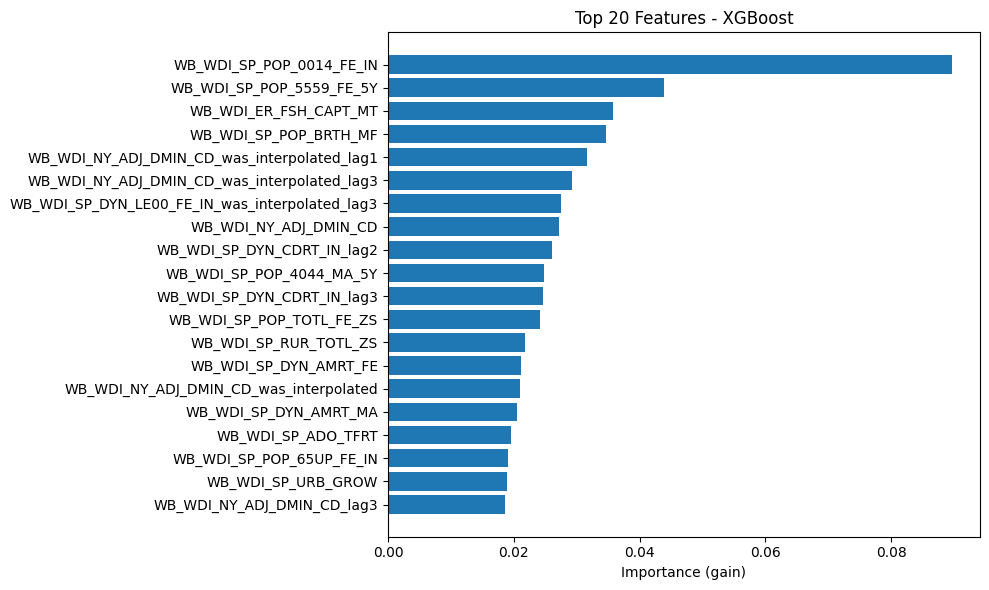

In [33]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_xgb_2

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

# Récupérer la feature importance par gain
importance_dict = best_model.get_booster().get_score(importance_type='gain')

# Convertir en DataFrame pour trier et afficher
importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher le tableau complet ou top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'].head(20)[::-1],
    importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (gain)')
plt.title('Top 20 Features - XGBoost')
plt.tight_layout()
plt.show()

#### CatBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [34]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_cat_2 = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=[1, scale_pos_weight],   # Classe 0 = poids 1, classe 1 = poids > 1
    random_seed=42,
    eval_metric="F1",
    loss_function="Logloss",
    verbose=0,
    early_stopping_rounds=30
)

# Entraînement
model_cat_2.fit(
    X_train_train, 
    y_train_train,
    eval_set=(X_train_val, y_train_val),
    verbose=0,           # affiche toutes les 50 itérations, mettre 0 pour silence total
    plot=False
)

# Prédiction
y_val_pred = model_cat_2.predict(X_train_val)

# Évaluation
acc_cat_d2 = accuracy_score(y_train_val, y_val_pred)
f1_cat_d2 = f1_score(y_train_val, y_val_pred)
precision_cat_d2 = precision_score(y_train_val, y_val_pred)
recall_cat_d2 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_cat_d2)
print("F1-score :", f1_cat_d2)
print("Precision:", precision_cat_d2)
print("Recall   :", recall_cat_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.7531956735496559
F1-score : 0.7355110642781876
Precision: 0.6924603174603174
Recall   : 0.7842696629213484

Confusion matrix:
 [[417 155]
 [ 96 349]]

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.73      0.77       572
           1       0.69      0.78      0.74       445

    accuracy                           0.75      1017
   macro avg       0.75      0.76      0.75      1017
weighted avg       0.76      0.75      0.75      1017



##### Feature importance

Top 20 features par importance :
                       Feature  Importance
0     WB_WDI_SP_POP_0014_FE_IN   29.197019
1        WB_WDI_ER_FSH_CAPT_MT   13.987350
2        WB_WDI_SP_POP_BRTH_MF   10.407936
3     WB_WDI_SP_POP_3539_MA_5Y    6.599053
4     WB_WDI_SP_POP_5054_FE_5Y    3.971070
5        WB_WDI_SP_DYN_AMRT_FE    3.449125
6     WB_WDI_SP_POP_4044_MA_5Y    3.109403
7     WB_WDI_SP_POP_1519_FE_5Y    2.772747
8        WB_WDI_SP_RUR_TOTL_ZS    2.723384
9   WB_WDI_SP_DYN_CDRT_IN_lag1    2.534264
10    WB_WDI_SP_POP_5559_FE_5Y    2.444328
11    WB_WDI_SP_POP_1564_FE_IN    2.034281
12     WB_WDI_SM_POP_NETM_lag1    1.680462
13       WB_WDI_NY_ADJ_DMIN_CD    1.551260
14    WB_WDI_SP_POP_4549_FE_5Y    1.365872
15  WB_WDI_SP_DYN_CDRT_IN_lag2    1.265236
16          WB_WDI_SP_ADO_TFRT    1.241689
17    WB_WDI_SP_POP_65UP_FE_IN    1.222616
18    WB_WDI_SP_POP_TOTL_FE_ZS    1.107937
19    WB_WDI_SP_POP_1014_FE_5Y    1.078794


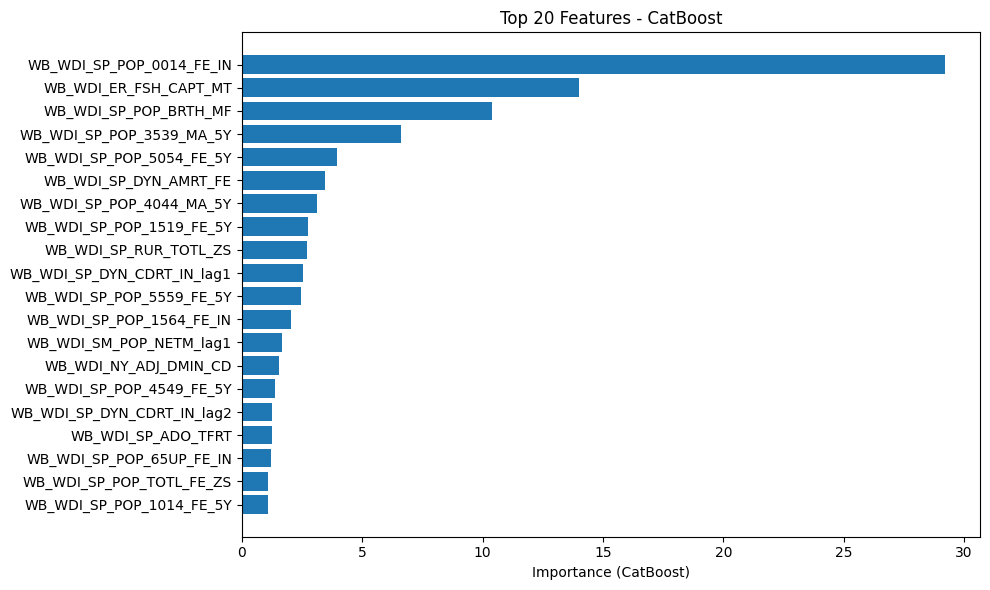

In [35]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_cat_2

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.get_feature_importance()

# Construire le DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Trier
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (CatBoost)')
plt.title('Top 20 Features - CatBoost')
plt.tight_layout()
plt.show()


#### RandomForest

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [36]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_rf_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entraînement
model_rf_2.fit(
    X_train_train, 
    y_train_train
)

# Prédiction
y_val_pred = model_rf_2.predict(X_train_val)

# Évaluation
acc_rf_d2 = accuracy_score(y_train_val, y_val_pred)
f1_rf_d2 = f1_score(y_train_val, y_val_pred)
precision_rf_d2 = precision_score(y_train_val, y_val_pred)
recall_rf_d2 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_rf_d2)
print("F1-score :", f1_rf_d2)
print("Precision:", precision_rf_d2)
print("Recall   :", recall_rf_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8190757128810227
F1-score : 0.7913832199546486
Precision: 0.7986270022883295
Recall   : 0.7842696629213484

Confusion matrix:
 [[484  88]
 [ 96 349]]

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       572
           1       0.80      0.78      0.79       445

    accuracy                           0.82      1017
   macro avg       0.82      0.82      0.82      1017
weighted avg       0.82      0.82      0.82      1017



##### Feature importance

Top 20 features par importance :
                     Feature  Importance
0   WB_WDI_SP_POP_0014_FE_IN    0.069877
1   WB_WDI_SP_POP_65UP_FE_IN    0.049586
2   WB_WDI_SP_POP_1564_FE_IN    0.049319
3      WB_WDI_ER_FSH_CAPT_MT    0.037849
4      WB_WDI_SP_POP_BRTH_MF    0.029469
5      WB_WDI_ER_FSH_AQUA_MT    0.027041
6   WB_WDI_SP_POP_5559_FE_5Y    0.023891
7   WB_WDI_SP_POP_TOTL_FE_ZS    0.023701
8      WB_WDI_SP_RUR_TOTL_ZS    0.023593
9    WB_WDI_SM_POP_NETM_lag1    0.020931
10        WB_WDI_SP_ADO_TFRT    0.020607
11   WB_WDI_SM_POP_NETM_lag3    0.020553
12  WB_WDI_SP_POP_4044_MA_5Y    0.020483
13        WB_WDI_SM_POP_NETM    0.020226
14     WB_WDI_SP_DYN_AMRT_MA    0.020174
15  WB_WDI_SP_POP_3539_MA_5Y    0.020161
16  WB_WDI_SP_POP_5054_FE_5Y    0.019352
17   WB_WDI_SM_POP_NETM_lag2    0.018947
18     WB_WDI_SP_DYN_AMRT_FE    0.018832
19   WB_WDI_SP_POP_GROW_lag3    0.018437


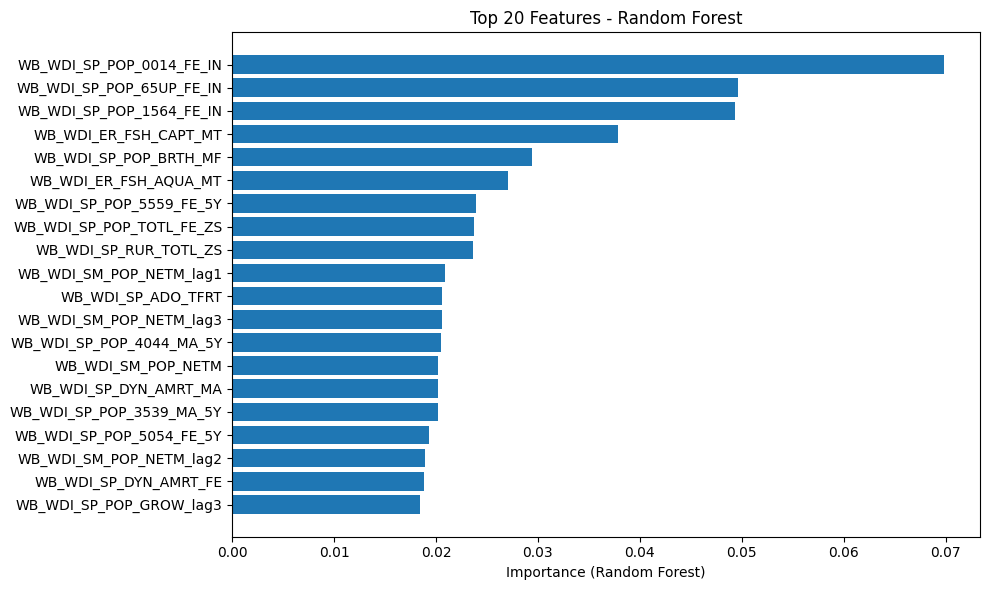

In [37]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_rf_2

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features par importance :")
print(importance_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (Random Forest)')
plt.title('Top 20 Features - Random Forest')
plt.tight_layout()
plt.show()


#### MLP

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [38]:
# Normalisation indispensable
scaler = StandardScaler()
X_train_train_scaled = scaler.fit_transform(X_train_train)
X_train_val_scaled = scaler.transform(X_train_val)

model_mlp_2 = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Entraînement
model_mlp_2.fit(X_train_train_scaled, y_train_train)

# Prédiction
y_pred = model_mlp_2.predict(X_train_val_scaled)

# Évaluation
acc_mlp_d2 = accuracy_score(y_train_val, y_pred)
f1_mlp_d2 = f1_score(y_train_val, y_pred)
precision_mlp_d2 = precision_score(y_train_val, y_pred)
recall_mlp_d2 = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_mlp_d2)
print("F1-score :", f1_mlp_d2)
print("Precision:", precision_mlp_d2)
print("Recall   :", recall_mlp_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.7738446411012783
F1-score : 0.7325581395348837
Precision: 0.7590361445783133
Recall   : 0.7078651685393258

Confusion matrix:
 [[472 100]
 [130 315]]

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       572
           1       0.76      0.71      0.73       445

    accuracy                           0.77      1017
   macro avg       0.77      0.77      0.77      1017
weighted avg       0.77      0.77      0.77      1017



##### Feature importance

In [39]:
from sklearn.inspection import permutation_importance

# Attention : nécessite que le modèle soit déjà entraîné
result = permutation_importance(
    model_mlp_2, 
    X_train_val_scaled, 
    y_train_val, 
    scoring='f1',
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X_train_train.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features par importance (Permutation Importance) :")
print(importance_df.head(20))


Top 20 features par importance (Permutation Importance) :
                       Feature  Importance
0     WB_WDI_SP_POP_0014_FE_IN    0.073743
1     WB_WDI_SP_POP_2529_FE_5Y    0.072854
2     WB_WDI_SP_POP_4549_FE_5Y    0.072379
3        WB_WDI_SP_DYN_AMRT_MA    0.071765
4     WB_WDI_SP_POP_4044_MA_5Y    0.067712
5           WB_WDI_SP_ADO_TFRT    0.064712
6     WB_WDI_SP_POP_2529_MA_5Y    0.061712
7        WB_WDI_SP_DYN_CBRT_IN    0.059490
8     WB_WDI_SP_POP_2024_FE_5Y    0.054067
9        WB_WDI_ER_FSH_CAPT_MT    0.053062
10    WB_WDI_SP_POP_1564_FE_IN    0.053004
11       WB_WDI_SP_POP_BRTH_MF    0.051577
12    WB_WDI_SP_POP_3539_FE_5Y    0.046075
13    WB_WDI_SP_POP_TOTL_FE_ZS    0.041952
14    WB_WDI_SP_POP_1014_FE_5Y    0.035192
15    WB_WDI_SP_POP_3539_MA_5Y    0.035151
16  WB_WDI_NY_ADJ_DMIN_CD_lag1    0.033512
17       WB_WDI_SP_DYN_AMRT_FE    0.032405
18       WB_WDI_SP_RUR_TOTL_ZS    0.031887
19    WB_WDI_SP_POP_2024_MA_5Y    0.031499


#### GradientBoosting

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [40]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

# Créer les sample_weights : poids pour les positifs
# Ici on donne au positif un poids = scale_pos_weight, négatif = 1
sample_weight = np.where(y_train_train == 1, scale_pos_weight, 1.0)

# Définition du modèle
model_gb_2 = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Entraînement avec sample_weight pour gérer le déséquilibre
model_gb_2.fit(X_train_train, y_train_train, sample_weight=sample_weight)

# Prédiction
y_pred = model_gb_2.predict(X_train_val)

# Évaluation
acc_gb_d2 = accuracy_score(y_train_val, y_pred)
f1_gb_d2 = f1_score(y_train_val, y_pred)
precision_gb_d2 = precision_score(y_train_val, y_pred)
recall_gb_d2 = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_gb_d2)
print("F1-score :", f1_gb_d2)
print("Precision:", precision_gb_d2)
print("Recall   :", recall_gb_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))

Accuracy : 0.8171091445427728
F1-score : 0.7881548974943052
Precision: 0.7990762124711316
Recall   : 0.7775280898876404

Confusion matrix:
 [[485  87]
 [ 99 346]]

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       572
           1       0.80      0.78      0.79       445

    accuracy                           0.82      1017
   macro avg       0.81      0.81      0.81      1017
weighted avg       0.82      0.82      0.82      1017



##### Feature importance

Top 20 features GradientBoosting:
                       Feature  Importance
0     WB_WDI_SP_POP_0014_FE_IN    0.208299
1        WB_WDI_ER_FSH_CAPT_MT    0.085489
2        WB_WDI_SP_POP_BRTH_MF    0.070537
3     WB_WDI_SP_POP_5559_FE_5Y    0.056816
4     WB_WDI_SP_POP_TOTL_FE_ZS    0.041543
5        WB_WDI_SP_RUR_TOTL_ZS    0.037346
6           WB_WDI_SP_ADO_TFRT    0.034218
7        WB_WDI_SP_DYN_AMRT_MA    0.028250
8        WB_WDI_SP_DYN_AMRT_FE    0.026907
9   WB_WDI_SP_DYN_CDRT_IN_lag3    0.023223
10    WB_WDI_SP_POP_4044_MA_5Y    0.022798
11    WB_WDI_SP_POP_3539_MA_5Y    0.022524
12    WB_WDI_SP_POP_65UP_FE_IN    0.022332
13          WB_WDI_SM_POP_NETM    0.022298
14          WB_WDI_SP_URB_GROW    0.015992
15       WB_WDI_NY_ADJ_DMIN_CD    0.014648
16    WB_WDI_SP_POP_1564_FE_IN    0.014636
17       WB_WDI_ER_FSH_AQUA_MT    0.014469
18       WB_WDI_SP_DYN_CDRT_IN    0.013010
19    WB_WDI_SP_POP_1519_FE_5Y    0.012241


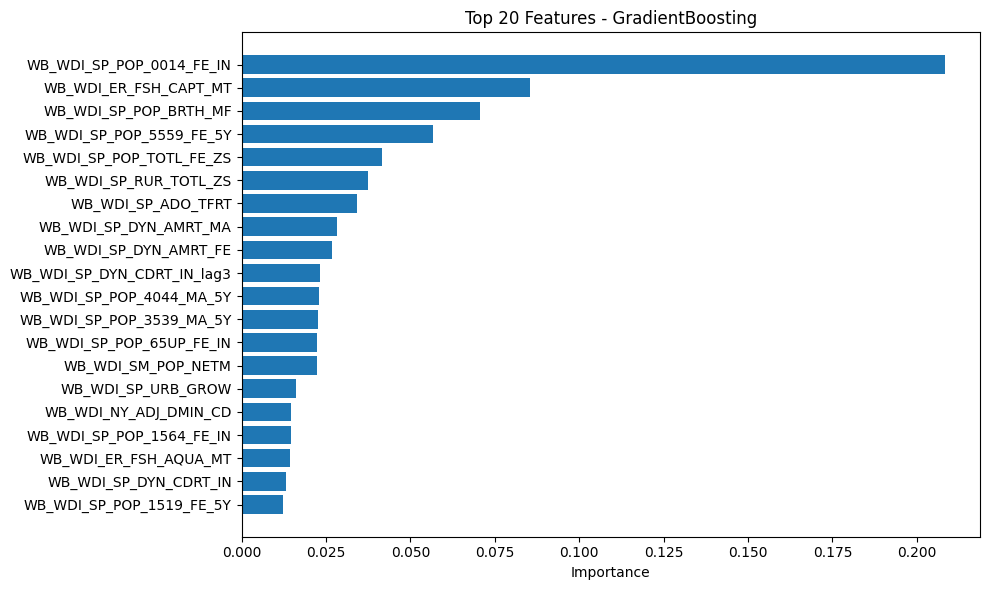

In [41]:
# Feature importance

feature_names = X_train_train.columns
importance_values = model_gb_2.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features GradientBoosting:")
print(importance_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance')
plt.title('Top 20 Features - GradientBoosting')
plt.tight_layout()
plt.show()

#### ExtraTrees

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [42]:
# Ajustement du déséquilibre
class_weights = {0: 1, 1: scale_pos_weight}

model_et_2 = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight=class_weights,
    random_state=42
)

# Entraînement
model_et_2.fit(X_train_train, y_train_train)

# Prédiction
y_pred = model_et_2.predict(X_train_val)

# Évaluation
acc_et_d2 = accuracy_score(y_train_val, y_pred)
f1_et_d2 = f1_score(y_train_val, y_pred)
precision_et_d2 = precision_score(y_train_val, y_pred)
recall_et_d2 = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_et_d2)
print("F1-score :", f1_et_d2)
print("Precision:", precision_et_d2)
print("Recall   :", recall_et_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.831858407079646
F1-score : 0.7932285368802902
Precision: 0.8586387434554974
Recall   : 0.7370786516853932

Confusion matrix:
 [[518  54]
 [117 328]]

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       572
           1       0.86      0.74      0.79       445

    accuracy                           0.83      1017
   macro avg       0.84      0.82      0.83      1017
weighted avg       0.83      0.83      0.83      1017



##### Feature importance

Top 20 features par importance :
                     Feature  Importance
0   WB_WDI_SP_POP_0014_FE_IN    0.046144
1   WB_WDI_SP_POP_1564_FE_IN    0.042621
2   WB_WDI_SP_POP_65UP_FE_IN    0.038212
3      WB_WDI_SP_POP_BRTH_MF    0.032872
4      WB_WDI_SP_RUR_TOTL_ZS    0.027724
5      WB_WDI_ER_FSH_CAPT_MT    0.027292
6   WB_WDI_SP_POP_TOTL_FE_ZS    0.025448
7   WB_WDI_SP_POP_5559_FE_5Y    0.024655
8         WB_WDI_SP_ADO_TFRT    0.022949
9   WB_WDI_SP_POP_5054_FE_5Y    0.022656
10  WB_WDI_SP_POP_4044_MA_5Y    0.022411
11  WB_WDI_SP_POP_4549_FE_5Y    0.021416
12  WB_WDI_SP_POP_3539_MA_5Y    0.021106
13     WB_WDI_ER_FSH_AQUA_MT    0.020600
14     WB_WDI_SP_DYN_AMRT_FE    0.020519
15     WB_WDI_SP_DYN_CBRT_IN    0.020416
16  WB_WDI_SP_POP_1564_FE_ZS    0.020382
17  WB_WDI_SP_POP_4044_FE_5Y    0.020275
18     WB_WDI_SP_DYN_AMRT_MA    0.020142
19  WB_WDI_SP_POP_1014_FE_5Y    0.020035


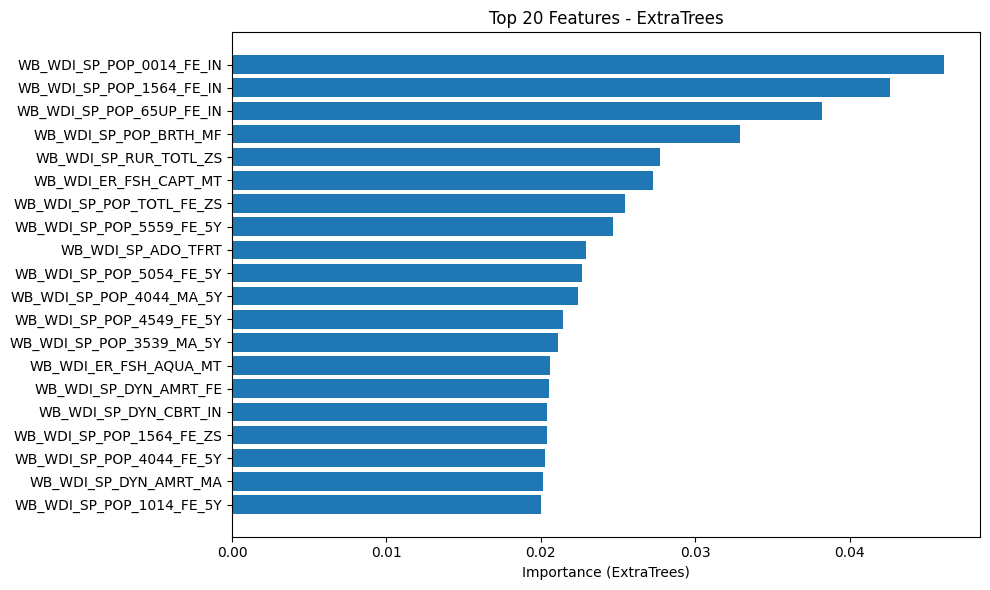

In [43]:
# Choisir le modèle à analyser
best_model = model_et_2

# Récupérer les importances
importance_values = best_model.feature_importances_
feature_names = X_train_train.columns

# Construire le DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Trier par importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (ExtraTrees)')
plt.title('Top 20 Features - ExtraTrees')
plt.tight_layout()
plt.show()


#### Tableau récap dataset 2 sans PCA

In [44]:
data_dataset2 = {
    'Model': ['XGBoost', 'CatBoost', 'RandomForest', 'MLP', 'GradientBoosting', 'ExtraTrees'],
    'Accuracy': [f"{acc_xgb_d2:.4f}",
                 f"{acc_cat_d2:.4f}",
                 f"{acc_rf_d2:.4f}",
                 f"{acc_mlp_d2:.4f}",
                 f"{acc_gb_d2:.4f}",
                 f"{acc_et_d2:.4f}"],
    'Precision': [f"{precision_xgb_d2:.4f}",
                  f"{precision_cat_d2:.4f}",
                  f"{precision_rf_d2:.4f}",
                  f"{precision_mlp_d2:.4f}",
                  f"{precision_gb_d2:.4f}",
                  f"{precision_et_d2:.4f}"],
    'Recall': [f"{recall_xgb_d2:.4f}",
               f"{recall_cat_d2:.4f}",
               f"{recall_rf_d2:.4f}",
               f"{recall_mlp_d2:.4f}",
               f"{recall_gb_d2:.4f}",
               f"{recall_et_d2:.4f}"],
    'F1-score': [f"{f1_xgb_d2:.4f}",
                 f"{f1_cat_d2:.4f}",
                 f"{f1_rf_d2:.4f}",
                 f"{f1_mlp_d2:.4f}",
                 f"{f1_gb_d2:.4f}",
                 f"{f1_et_d2:.4f}"]
}

df_results = pd.DataFrame(data_dataset2)
df_results


,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.8545,0.8631,0.7933,0.8267
1,CatBoost,0.7532,0.6925,0.7843,0.7355
2,RandomForest,0.8191,0.7986,0.7843,0.7914
3,MLP,0.7738,0.7590,0.7079,0.7326
4,GradientBoosting,0.8171,0.7991,0.7775,0.7882
5,ExtraTrees,0.8319,0.8586,0.7371,0.7932


## Dataset 2 Interpolated avec PCA

#### Récupération du dataset2 avec PCA

In [75]:
dataset2 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset2_lagged_pca_final.csv")
dataset2

,REF_AREA,TIME_PERIOD,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,war_nextYear
0,AFG,1963,10.146637,-0.143931,-5.176508,9.084302,-2.081329,-1.785381,2.015364,-4.063669,-1.690567,-1.610775,1.615453,1.978742,-0.181017,-0.300636,1.321512,0.446809,0
1,AFG,1964,10.183131,-0.138293,-5.099614,8.850889,-2.070096,-1.718669,1.955934,-3.948788,-1.637008,-1.488476,1.580643,1.893472,-0.115500,-0.297052,1.269338,0.417448,0
2,AFG,1965,10.242231,-0.132339,-5.041062,8.613171,-2.087588,-1.658920,1.910277,-3.819288,-1.596475,-1.351103,1.525553,1.816540,-0.049639,-0.283149,1.203341,0.390883,0
3,AFG,1966,10.321320,-0.125639,-4.996430,8.359689,-2.116067,-1.603981,1.868831,-3.676212,-1.577760,-1.226683,1.449069,1.738874,0.018575,-0.259828,1.119190,0.348881,0
4,AFG,1967,10.413445,-0.118994,-4.958851,8.089051,-2.152776,-1.552199,1.833893,-3.523686,-1.563393,-1.103648,1.370123,1.674087,0.076267,-0.232371,1.011835,0.292111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6436,ZWE,2019,5.723890,-0.669133,0.783587,0.980803,1.702697,3.447429,-3.963549,5.039228,3.747760,-3.838088,2.337724,-3.065480,0.091381,-1.115572,0.098635,0.507509,0
6437,ZWE,2020,5.388619,-0.718894,0.701379,0.584955,2.060821,3.534814,-4.441107,3.771122,4.047855,-3.384832,2.438005,-3.312057,0.544933,-1.146028,0.144741,0.284949,0
6438,ZWE,2021,5.199970,-0.736312,0.543981,0.442325,2.606222,3.536418,-4.576987,2.422282,4.297395,-2.924450,2.420118,-3.463501,1.014533,-1.227214,0.066419,0.018105,0
6439,ZWE,2022,4.968983,-0.745006,0.620056,0.190516,3.200373,3.428577,-4.608962,1.221608,4.335675,-2.324920,2.229639,-3.652853,1.438918,-1.197927,-0.094173,-0.251655,0


#### Découpage train/validation/test

In [76]:
train_full = dataset2[dataset2["TIME_PERIOD"] <= 2010]
test  = dataset2[dataset2["TIME_PERIOD"] >= 2012]

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

print(f"Dataset2   => {dataset2.shape}")
print(f"Train_full => {train_full.shape}")
print(f"Test       => {test.shape}")
print(f"Train_full : X_train_full => {X_train_full.shape} - y_train_full => {y_train_full.shape}")
print(f"Test       : X_test       => {X_test.shape} - y_test       => {y_test.shape}")

print(f"X_train_train => {X_train_train.shape}")
print(f"y_train_train => {y_train_train.shape}")
print(f"X_train_val   => {X_train_val.shape}")
print(f"y_train_val   => {y_train_val.shape}")

Dataset2   => (6441, 19)
Train_full => (5424, 19)
Test       => (1017, 19)
Train_full : X_train_full => (5424, 16) - y_train_full => (5424,)
Test       : X_test       => (1017, 16) - y_test       => (1017,)
X_train_train => (4407, 16)
y_train_train => (4407,)
X_train_val   => (1017, 16)
y_train_val   => (1017,)


#### XGBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [79]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_xgb_2_pca = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Entraînement
model_xgb_2_pca.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_train, y_train_train), (X_train_val, y_train_val)], 
    verbose=False
)

# Prédiction
y_val_pred = model_xgb_2_pca.predict(X_train_val)

# Évaluation
acc_xgb_d2_pca = accuracy_score(y_train_val, y_val_pred)
f1_xgb_d2_pca = f1_score(y_train_val, y_val_pred)
precision_xgb_d2_pca = precision_score(y_train_val, y_val_pred)
recall_xgb_d2_pca = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_xgb_d2_pca)
print("F1-score :", f1_xgb_d2_pca)
print("Precision:", precision_xgb_d2_pca)
print("Recall   :", recall_xgb_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.7935103244837758
F1-score : 0.7475961538461539
Precision: 0.8036175710594315
Recall   : 0.698876404494382

Confusion matrix:
 [[496  76]
 [134 311]]

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.87      0.83       572
           1       0.80      0.70      0.75       445

    accuracy                           0.79      1017
   macro avg       0.80      0.78      0.79      1017
weighted avg       0.79      0.79      0.79      1017



#### CatBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [48]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_cat_2_pca = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=[1, scale_pos_weight],   # Classe 0 = poids 1, classe 1 = poids > 1
    random_seed=42,
    eval_metric="F1",
    loss_function="Logloss",
    verbose=0,
    early_stopping_rounds=30
)

# Entraînement
model_cat_2_pca.fit(
    X_train_train, 
    y_train_train,
    eval_set=(X_train_val, y_train_val),
    verbose=0,           # affiche toutes les 50 itérations, mettre 0 pour silence total
    plot=False
)

# Prédiction
y_val_pred = model_cat_2_pca.predict(X_train_val)

# Évaluation
acc_cat_d2_pca = accuracy_score(y_train_val, y_val_pred)
f1_cat_d2_pca = f1_score(y_train_val, y_val_pred)
precision_cat_d2_pca = precision_score(y_train_val, y_val_pred)
recall_cat_d2_pca = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_cat_d2_pca)
print("F1-score :", f1_cat_d2_pca)
print("Precision:", precision_cat_d2_pca)
print("Recall   :", recall_cat_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.7748279252704031
F1-score : 0.7524324324324324
Precision: 0.725
Recall   : 0.7820224719101123

Confusion matrix:
 [[440 132]
 [ 97 348]]

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79       572
           1       0.72      0.78      0.75       445

    accuracy                           0.77      1017
   macro avg       0.77      0.78      0.77      1017
weighted avg       0.78      0.77      0.78      1017



#### RandomForest

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [49]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_rf_2_pca = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entraînement
model_rf_2_pca.fit(
    X_train_train, 
    y_train_train
)

# Prédiction
y_val_pred = model_rf_2_pca.predict(X_train_val)

# Évaluation
acc_rf_d2_pca = accuracy_score(y_train_val, y_val_pred)
f1_rf_d2_pca = f1_score(y_train_val, y_val_pred)
precision_rf_d2_pca = precision_score(y_train_val, y_val_pred)
recall_rf_d2_pca = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_rf_d2_pca)
print("F1-score :", f1_rf_d2_pca)
print("Precision:", precision_rf_d2_pca)
print("Recall   :", recall_rf_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8092428711897739
F1-score : 0.7581047381546134
Precision: 0.8515406162464986
Recall   : 0.6831460674157304

Confusion matrix:
 [[519  53]
 [141 304]]

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.84       572
           1       0.85      0.68      0.76       445

    accuracy                           0.81      1017
   macro avg       0.82      0.80      0.80      1017
weighted avg       0.81      0.81      0.81      1017



#### MLP

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [50]:
# Normalisation indispensable
scaler = StandardScaler()
X_train_train_scaled = scaler.fit_transform(X_train_train)
X_train_val_scaled = scaler.transform(X_train_val)

model_mlp_2_pca = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Entraînement
model_mlp_2_pca.fit(X_train_train_scaled, y_train_train)

# Prédiction
y_pred = model_mlp_2_pca.predict(X_train_val_scaled)

# Évaluation
acc_mlp_d2_pca = accuracy_score(y_train_val, y_pred)
f1_mlp_d2_pca = f1_score(y_train_val, y_pred)
precision_mlp_d2_pca = precision_score(y_train_val, y_pred)
recall_mlp_d2_pca = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_mlp_d2_pca)
print("F1-score :", f1_mlp_d2_pca)
print("Precision:", precision_mlp_d2_pca)
print("Recall   :", recall_mlp_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.7777777777777778
F1-score : 0.7196029776674938
Precision: 0.8033240997229917
Recall   : 0.651685393258427

Confusion matrix:
 [[501  71]
 [155 290]]

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.88      0.82       572
           1       0.80      0.65      0.72       445

    accuracy                           0.78      1017
   macro avg       0.78      0.76      0.77      1017
weighted avg       0.78      0.78      0.77      1017



#### GradientBoosting

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [51]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

# Créer les sample_weights : poids pour les positifs
# Ici on donne au positif un poids = scale_pos_weight, négatif = 1
sample_weight = np.where(y_train_train == 1, scale_pos_weight, 1.0)

# Définition du modèle
model_gb_2_pca = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Entraînement avec sample_weight pour gérer le déséquilibre
model_gb_2_pca.fit(X_train_train, y_train_train, sample_weight=sample_weight)

# Prédiction
y_pred = model_gb_2_pca.predict(X_train_val)

# Évaluation
acc_gb_d2_pca = accuracy_score(y_train_val, y_pred)
f1_gb_d2_pca = f1_score(y_train_val, y_pred)
precision_gb_d2_pca = precision_score(y_train_val, y_pred)
recall_gb_d2_pca = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_gb_d2_pca)
print("F1-score :", f1_gb_d2_pca)
print("Precision:", precision_gb_d2_pca)
print("Recall   :", recall_gb_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))

Accuracy : 0.7571288102261554
F1-score : 0.6984126984126984
Precision: 0.7647058823529411
Recall   : 0.6426966292134831

Confusion matrix:
 [[484  88]
 [159 286]]

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80       572
           1       0.76      0.64      0.70       445

    accuracy                           0.76      1017
   macro avg       0.76      0.74      0.75      1017
weighted avg       0.76      0.76      0.75      1017



#### ExtraTrees

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [52]:
# Ajustement du déséquilibre
class_weights = {0: 1, 1: scale_pos_weight}

model_et_2_pca = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight=class_weights,
    random_state=42
)

# Entraînement
model_et_2_pca.fit(X_train_train, y_train_train)

# Prédiction
y_pred = model_et_2_pca.predict(X_train_val)

# Évaluation
acc_et_d2_pca = accuracy_score(y_train_val, y_pred)
f1_et_d2_pca = f1_score(y_train_val, y_pred)
precision_et_d2_pca = precision_score(y_train_val, y_pred)
recall_et_d2_pca = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_et_d2_pca)
print("F1-score :", f1_et_d2_pca)
print("Precision:", precision_et_d2_pca)
print("Recall   :", recall_et_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.8269419862340216
F1-score : 0.7755102040816326
Precision: 0.8967551622418879
Recall   : 0.6831460674157304

Confusion matrix:
 [[537  35]
 [141 304]]

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.94      0.86       572
           1       0.90      0.68      0.78       445

    accuracy                           0.83      1017
   macro avg       0.84      0.81      0.82      1017
weighted avg       0.84      0.83      0.82      1017



#### SVM

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [ ]:
# Ajustement du déséquilibre (équivalent de scale_pos_weight)
class_weight = {
    0: 1,
    1: y_train_train.value_counts()[0] / y_train_train.value_counts()[1]
}

# Modèle SVM
model_svm_2_pca = SVC(
    kernel="rbf",
    C=0.1,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

# Entraînement
model_svm_2_pca.fit(
    X_train_train,
    y_train_train
)

# Prédiction
y_val_pred = model_svm_2_pca.predict(X_train_val)

# Évaluation
acc_svm_d2_pca = accuracy_score(y_train_val, y_val_pred)
f1_svm_d2_pca = f1_score(y_train_val, y_val_pred)
precision_svm_d2_pca = precision_score(y_train_val, y_val_pred)
recall_svm_d2_pca = recall_score(y_train_val, y_val_pred)

print("Accuracy :", acc_svm_d2_pca)
print("F1-score :", f1_svm_d2_pca)
print("Precision:", precision_svm_d2_pca)
print("Recall   :", recall_svm_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))


Accuracy : 0.688298918387414
F1-score : 0.6401816118047673
Precision: 0.6467889908256881
Recall   : 0.6337078651685393

Confusion matrix:
 [[418 154]
 [163 282]]

Classification report:
               precision    recall  f1-score   support

           0       0.72      0.73      0.73       572
           1       0.65      0.63      0.64       445

    accuracy                           0.69      1017
   macro avg       0.68      0.68      0.68      1017
weighted avg       0.69      0.69      0.69      1017



#### Tableau récap dataset 2 avec PCA

In [53]:
data_dataset2_pca = {
    'Model': ['XGBoost', 'CatBoost', 'RandomForest', 'MLP', 'GradientBoosting', 'ExtraTrees'],
    'Accuracy': [f"{acc_xgb_d2_pca:.4f}",
                 f"{acc_cat_d2_pca:.4f}",
                 f"{acc_rf_d2_pca:.4f}",
                 f"{acc_mlp_d2_pca:.4f}",
                 f"{acc_gb_d2_pca:.4f}",
                 f"{acc_et_d2_pca:.4f}"],
    'Precision': [f"{precision_xgb_d2_pca:.4f}",
                  f"{precision_cat_d2_pca:.4f}",
                  f"{precision_rf_d2_pca:.4f}",
                  f"{precision_mlp_d2_pca:.4f}",
                  f"{precision_gb_d2_pca:.4f}",
                  f"{precision_et_d2_pca:.4f}"],
    'Recall': [f"{recall_xgb_d2_pca:.4f}",
               f"{recall_cat_d2_pca:.4f}",
               f"{recall_rf_d2_pca:.4f}",
               f"{recall_mlp_d2_pca:.4f}",
               f"{recall_gb_d2_pca:.4f}",
               f"{recall_et_d2_pca:.4f}"],
    'F1-score': [f"{f1_xgb_d2_pca:.4f}",
                 f"{f1_cat_d2_pca:.4f}",
                 f"{f1_rf_d2_pca:.4f}",
                 f"{f1_mlp_d2_pca:.4f}",
                 f"{f1_gb_d2_pca:.4f}",
                 f"{f1_et_d2_pca:.4f}"]
}

df_results = pd.DataFrame(data_dataset2_pca)
df_results


,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.7935,0.8036,0.6989,0.7476
1,CatBoost,0.7748,0.7250,0.7820,0.7524
2,RandomForest,0.8092,0.8515,0.6831,0.7581
3,MLP,0.7778,0.8033,0.6517,0.7196
4,GradientBoosting,0.7571,0.7647,0.6427,0.6984
5,ExtraTrees,0.8269,0.8968,0.6831,0.7755


## Tableau récapitulatif final

In [54]:
data_long = []

datasets = [('Dataset 1', data_dataset1), ('Dataset 2', data_dataset2), ('Dataset 2 PCA', data_dataset2_pca)]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
model_order = ['XGBoost', 'CatBoost', 'RandomForest', 'LightGBM', 'MLP', 'GradientBoosting', 'ExtraTrees']

for ds_name, data_dict in datasets:
    models = data_dict['Model']
    for metric in metrics:
        for model, value in zip(models, data_dict[metric]):
            data_long.append({
                'Dataset': ds_name,
                'Metric': metric,
                'Model': model,
                'Value': float(value)
            })

df_long = pd.DataFrame(data_long)

# Pivot pour avoir les modèles en colonnes, datasets en lignes, métriques en sous-index
df_pivot = df_long.pivot_table(index=['Dataset', 'Metric'], columns='Model', values='Value')
df_pivot = df_pivot.reindex(columns=model_order)

df_pivot

Model                    XGBoost  CatBoost  RandomForest  LightGBM     MLP  \
Dataset       Metric                                                         
Dataset 1     Accuracy    0.9184    0.8968        0.9282    0.9174     NaN   
              F1-score    0.9066    0.8872        0.9190    0.9054     NaN   
              Precision   0.9077    0.8498        0.9079    0.9074     NaN   
              Recall      0.9056    0.9281        0.9303    0.9034     NaN   
Dataset 2     Accuracy    0.8545    0.7532        0.8191       NaN  0.7738   
              F1-score    0.8267    0.7355        0.7914       NaN  0.7326   
              Precision   0.8631    0.6925        0.7986       NaN  0.7590   
              Recall      0.7933    0.7843        0.7843       NaN  0.7079   
Dataset 2 PCA Accuracy    0.7935    0.7748        0.8092       NaN  0.7778   
              F1-score    0.7476    0.7524        0.7581       NaN  0.7196   
              Precision   0.8036    0.7250        0.8515       NaN  0.8033   
              Recall      0.6989    0.7820        0.6831       NaN  0.6517   

Model                    GradientBoosting  ExtraTrees  
Dataset       Metric                                   
Dataset 1     Accuracy                NaN         NaN  
              F1-score                NaN         NaN  
              Precision               NaN         NaN  
              Recall                  NaN         NaN  
Dataset 2     Accuracy             0.8171      0.8319  
              F1-score             0.7882      0.7932  
              Precision            0.7991      0.8586  
              Recall               0.7775      0.7371  
Dataset 2 PCA Accuracy             0.7571      0.8269  
              F1-score             0.6984      0.7755  
              Precision            0.7647      0.8968  
              Recall               0.6427      0.6831

# Affichage final sur test

In [64]:
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
)

dataset1 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset1_lagged_final.csv")
train_full = dataset1[dataset1["TIME_PERIOD"] <= 2010]
test  = dataset1[dataset1["TIME_PERIOD"] >= 2012]

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

cols_subset = train_full.select_dtypes(include='number').columns[1:5]

cov_matrix = train_full[cols_subset].cov()

# numeric_df = dataset1.select_dtypes(include='number')
# cov_matrix = numeric_df.cov()


cols_to_check = [c for c in train_full.columns if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]]
data_numeric = train_full[cols_to_check]
corr_matrix = data_numeric.corr().abs()
threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

train_full = train_full.drop(columns=list(to_drop))
test = test.drop(columns=list(to_drop))

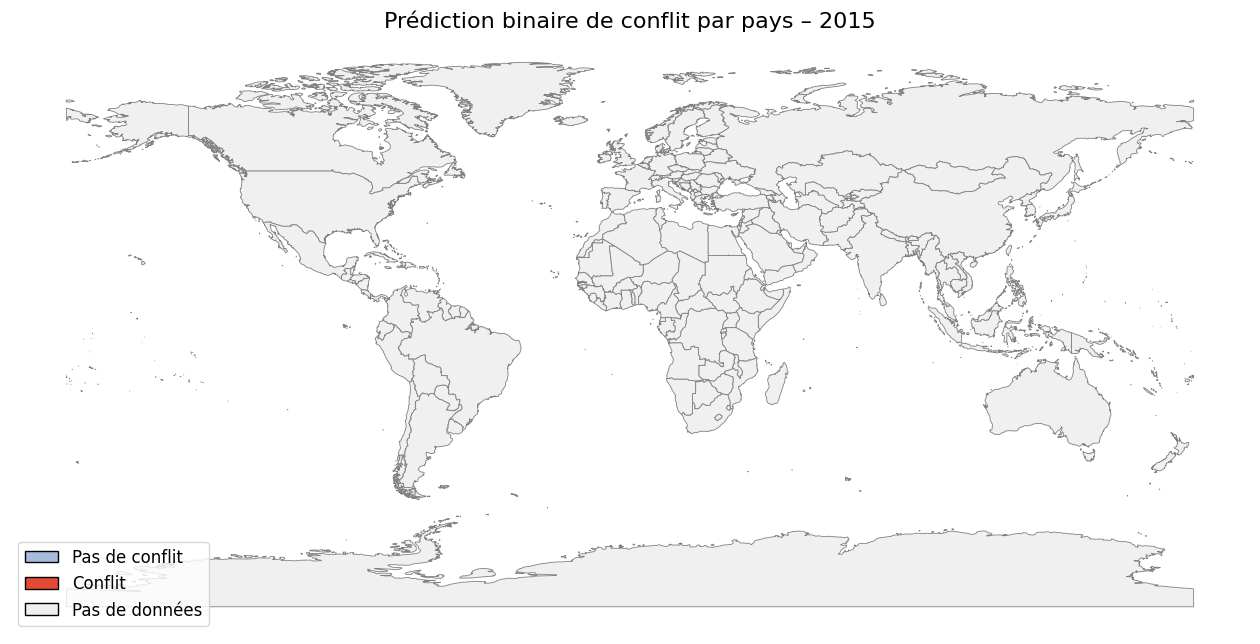

In [69]:
best_model = model_rf_1
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred  = best_model.predict(X_test)

dataset = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset1_lagged_final.csv")
dataset = dataset.copy()
df_pred_test = test.copy()

df_pred_test["proba_conflict"] = y_test_proba
df_pred_test["y_pred"] = y_test_pred

df_pred_test["y_true"] = y_test

# on extrait une année pour la visualisation
df_2015 = df_pred_test[df_pred_test["TIME_PERIOD"] == "2014-01-01"]


# code pour remplacer les code ISO_A3 dans le df qui sont à -99 et mettre la valeur de ADMIN

# créer un dict pour tous les -99
replace_dict = {}

# recupère les lignes avec ISO_A3 = -99
missing_iso = world[world["ISO_A3"] == "-99"]

for idx, row in missing_iso.iterrows():
    admin = row["ADMIN"]
    # transformer le nom du pays en code ISO-3 on peut le faire avec pycountry
    try:
        country = pycountry.countries.lookup(admin)
        replace_dict[idx] = country.alpha_3
    except LookupError:
        replace_dict[idx] = "-99" # sinon on laisse -99

# remplace dans world
for idx, iso in replace_dict.items():
    world.at[idx, "ISO_A3"] = iso




world_pred = world.merge(
    df_2015,
    left_on="ISO_A3",
    right_on="REF_AREA",
    how="left"
)





from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# palette douce
cmap_binary = ListedColormap(["#a6bddb", "#e34a33"])  # bleu clair / rouge foncé

# légende plus jolie
legend_elements = [
    mpatches.Patch(facecolor="#a6bddb", edgecolor="k", label="Pas de conflit"),
    mpatches.Patch(facecolor="#e34a33", edgecolor="k", label="Conflit"),
    mpatches.Patch(facecolor="#f0f0f0", edgecolor="k", label="Pas de données")
]

fig, ax = plt.subplots(1, 1, figsize=(16, 9))

world_pred.plot(
    column="y_pred",
    cmap=cmap_binary,
    linewidth=0.6,
    edgecolor="0.5",
    ax=ax,
    missing_kwds={"color": "#f0f0f0"}  # gris clair pour no data
)

ax.legend(handles=legend_elements, loc="lower left", frameon=True, facecolor="white", fontsize=12)
ax.set_title("Prédiction binaire de conflit par pays – 2015", fontsize=16)
ax.axis("off")

plt.show()